# Diabetes Prediction: Model Comparison & Fairness Analysis

## Abstract

This study investigates how different machine learning models and feature subsets affect the prediction of diabetes using the CDC's Behavioral Risk Factor Surveillance System (BRFSS) 2015 dataset (251,467 respondents, 22 features). We train three models (Logistic Regression, Random Forest, and a Multi-Layer Perceptron Neural Network) across five feature configurations, systematically removing feature groups (health conditions, lifestyle behaviors, demographics, and healthcare access) to measure their predictive contribution. Beyond overall accuracy, we evaluate fairness by examining how model performance varies across demographic subgroups defined by sex, age, race, income, and education. Our results reveal that health condition features dominate predictive performance, that simpler models match or outperform complex ones on this tabular dataset, and that removing demographic features does not uniformly improve fairness across all subgroups.

## 1. Introduction

Diabetes affects over 37 million Americans, with an additional 96 million classified as prediabetic (CDC, 2022). Early identification of at-risk individuals is critical for intervention, but predictive models must be scrutinized not only for accuracy but also for equitable performance across demographic groups. A model that performs well overall but poorly for certain populations could exacerbate existing health disparities.

This project addresses three core research questions:

1. **Feature importance**: Which categories of features (health conditions, lifestyle, demographics, healthcare access) contribute most to diabetes prediction? What happens to model performance when each group is systematically removed?
2. **Model comparison**: How do models of varying complexity (a linear model, an ensemble method, and a neural network) compare in predictive performance and robustness to feature removal?
3. **Fairness**: Do these models exhibit performance disparities across demographic subgroups (sex, age, race, income, education)? Does removing demographic features from the model reduce or worsen these disparities?

### Experimental Design

We conduct **15 experiments** (3 models × 5 feature configurations) using a consistent evaluation pipeline. Each model is trained on the same training split with the same random seed, and evaluated using identical metrics on the same held-out test set, ensuring that all comparisons are fair and reproducible.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
import os

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, roc_curve,
    ConfusionMatrixDisplay
)
from sklearn.inspection import permutation_importance

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams['figure.dpi'] = 150

os.makedirs('figures', exist_ok=True)
os.makedirs('data/processed', exist_ok=True)

RANDOM_STATE = 42
print('All imports loaded successfully.')

All imports loaded successfully.


## 2. Evaluation Methodology

### 2.1 Metrics

We evaluate each experiment using five complementary metrics, each capturing a different aspect of classifier performance. In the context of diabetes prediction, a **positive** prediction means the model predicts the patient has prediabetes or diabetes.

| Metric | Formula | What It Measures | Why It Matters Here |
|--------|---------|-----------------|-------------------|
| **Accuracy** | $\frac{TP + TN}{N}$ | Overall correctness | Baseline measure, but misleading under class imbalance. A naive "always predict no diabetes" classifier achieves 84.3% accuracy |
| **Precision** | $\frac{TP}{TP + FP}$ | Of those predicted positive, how many truly are | High precision means fewer false alarms, which is important for reducing unnecessary follow-up testing |
| **Recall (Sensitivity)** | $\frac{TP}{TP + FN}$ | Of actual positives, how many are detected | Critical in healthcare because missing a diabetic patient (false negative) is potentially more harmful than a false alarm |
| **F1 Score** | $\frac{2 \times Precision \times Recall}{Precision + Recall}$ | Harmonic mean of precision and recall | Balances the precision-recall trade-off; our **primary comparison metric** because it accounts for class imbalance better than accuracy |
| **ROC-AUC** | Area under the ROC curve | Probability that the model ranks a random positive higher than a random negative | Threshold-independent measure of discrimination ability; robust to class imbalance |

**Why F1 is our primary metric:** With a 5.4:1 class imbalance (only 15.7% of samples are positive), accuracy alone is deceptive. A model predicting "no diabetes" for everyone would score 84.3% accuracy but 0% recall, making it completely useless clinically. The F1 score penalizes both missed cases (low recall) and false alarms (low precision), making it the most informative single metric for this problem.

### 2.2 Class Imbalance Handling

The dataset has a significant class imbalance: 84.3% negative (no diabetes) vs. 15.7% positive (prediabetes/diabetes). Without correction, models will learn to favor the majority class, resulting in high accuracy but low recall. We apply three different strategies, matching each model's capabilities:

- **Logistic Regression & Random Forest**: `class_weight='balanced'`. Scikit-learn internally adjusts the loss function to weight minority-class errors higher by a factor proportional to the imbalance ratio (~5.4×). This is mathematically equivalent to resampling without actually duplicating data.
- **Neural Network (MLP)**: `MLPClassifier` does not support `class_weight`, so we apply **random oversampling**, which involves duplicating minority-class training samples until both classes are equally represented. This is a simpler alternative to SMOTE that avoids introducing synthetic data points, which could distort the feature distributions of our mostly-binary features.

### 2.3 Data Splitting and Preprocessing

- **Split**: 70% train / 15% validation / 15% test, stratified by the target variable to preserve the 15.7% positive rate in all splits
- **Scaling**: `StandardScaler` (z-score normalization) applied to the 3 continuous features (BMI, MentHlth, PhysHlth), fitted on **training data only** to prevent data leakage, then applied to validation and test sets
- **No encoding changes**: Binary and ordinal features kept as integers. `Race` (nominal, 1-8) kept as integer-coded. Tree models handle this naturally, and for logistic regression the coefficients remain interpretable
- **Random seed**: 42 throughout for full reproducibility

## 3. Data Pipeline: Correcting Data Leakage

The original preprocessing in `eda_and_preprocessing.ipynb` contained a subtle but important error: the `StandardScaler` was fitted on the **entire dataset** before splitting into train/validation/test sets. This means the scaler's mean and standard deviation incorporated information from the validation and test sets, causing **data leakage**. The model indirectly sees information about the data it will be evaluated on.

While the practical impact on this dataset is small (the splits are large enough that means and standard deviations are similar), fixing this is important for methodological rigor. In production settings with smaller or more heterogeneous datasets, data leakage through preprocessing can cause significant overestimation of model performance.

Below, we reload the raw CSV, split **first**, then fit the scaler on training data only.

In [2]:
df = pd.read_csv('data/diabetes_binary_health_indicators_BRFSS2015_with_race.csv')
print(f'Dataset shape: {df.shape}')
print('Target distribution:')
print(df['Diabetes_binary'].value_counts())
print(f'Positive rate: {df["Diabetes_binary"].mean():.4f}')

X = df.drop(columns=['Diabetes_binary'])
y = df['Diabetes_binary']

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=RANDOM_STATE
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=RANDOM_STATE
)

print()
print('Split sizes:')
print(f'  Train: {len(X_train):,} ({len(X_train)/len(df):.1%})')
print(f'  Val:   {len(X_val):,}  ({len(X_val)/len(df):.1%})')
print(f'  Test:  {len(X_test):,}  ({len(X_test)/len(df):.1%})')
for name, ys in [('Train', y_train), ('Val', y_val), ('Test', y_test)]:
    print(f'  {name} positive rate: {ys.mean():.4f}')

CONTINUOUS = ['BMI', 'MentHlth', 'PhysHlth']
scaler = StandardScaler()

X_train = X_train.copy()
X_val = X_val.copy()
X_test = X_test.copy()

X_train[CONTINUOUS] = scaler.fit_transform(X_train[CONTINUOUS])
X_val[CONTINUOUS] = scaler.transform(X_val[CONTINUOUS])
X_test[CONTINUOUS] = scaler.transform(X_test[CONTINUOUS])

pd.concat([X_train, y_train], axis=1).to_csv('data/processed/train.csv', index=False)
pd.concat([X_val, y_val], axis=1).to_csv('data/processed/val.csv', index=False)
pd.concat([X_test, y_test], axis=1).to_csv('data/processed/test.csv', index=False)
joblib.dump(scaler, 'data/processed/scaler.joblib')

print()
print('Scaler fitted on training data only:')
print(f'  Means: {dict(zip(CONTINUOUS, scaler.mean_))}')
print(f'  Stds:  {dict(zip(CONTINUOUS, scaler.scale_))}')
print('Corrected splits saved to data/processed/')

Dataset shape: (251467, 23)
Target distribution:
Diabetes_binary
0.0    211900
1.0     39567
Name: count, dtype: int64
Positive rate: 0.1573



Split sizes:
  Train: 176,026 (70.0%)
  Val:   37,720  (15.0%)
  Test:  37,721  (15.0%)
  Train positive rate: 0.1573
  Val positive rate: 0.1573
  Test positive rate: 0.1573



Scaler fitted on training data only:
  Means: {'BMI': np.float64(28.378591798938793), 'MentHlth': np.float64(3.1632315680638086), 'PhysHlth': np.float64(4.224392987399589)}
  Stds:  {'BMI': np.float64(6.587090401090488), 'MentHlth': np.float64(7.375936901883645), 'PhysHlth': np.float64(8.691937031534186)}
Corrected splits saved to data/processed/


### Data Characteristics

The dataset contains **251,467 observations** with zero missing values. It is a clean dataset derived from the CDC's BRFSS telephone survey.

**Class Imbalance**: The 5.4:1 ratio (84.3% negative, 15.7% positive) reflects the actual population prevalence of diabetes and prediabetes in the survey. This is a realistic imbalance, not artificially constructed, which makes it a good testbed for understanding how models handle real-world skewed distributions. The stratified split ensures all three sets maintain this 15.7% positive rate, preventing any split from being unrepresentatively skewed.

**Scaling**: Only 3 of 22 features are continuous (BMI, MentHlth, PhysHlth). The remaining 19 are binary or ordinal integers. Standardization of the continuous features ensures they don't dominate distance-based or gradient-based models purely due to scale differences. For instance, raw BMI values (12-98) would otherwise outweigh binary features (0-1) in logistic regression's linear combination.

## 4. Feature Groups and Leave-Out Experiment Design

A central question of this project is: **which types of features matter most for diabetes prediction, and how does their removal affect both performance and fairness?**

To answer this, we organize the 22 features into four semantically meaningful groups:

- **Health Conditions (10 features)**: Direct clinical indicators including blood pressure, cholesterol, BMI, stroke history, heart disease, general health, mental/physical health days, mobility difficulty. These are the most clinically proximal to diabetes.
- **Lifestyle Behaviors (5 features)**: Modifiable behaviors including smoking, physical activity, fruit/vegetable consumption, heavy alcohol use. These capture behavioral risk factors.
- **Demographics (5 features)**: Sex, age, education, income, race. These capture population-level risk variation and are central to our fairness analysis.
- **Healthcare Access (2 features)**: Insurance coverage and cost barriers. These capture structural access to care.

We then define **5 experimental configurations**:
1. **Full** (22 features): the baseline with all features
2. **No Health** (12 features): removes the 10 health condition features
3. **No Lifestyle** (17 features): removes the 5 lifestyle features
4. **No Demographics** (17 features): removes the 5 demographic features
5. **No Healthcare** (20 features): removes the 2 healthcare access features

By comparing each leave-out configuration against the full baseline, we can quantify the **marginal contribution** of each feature group. A large performance drop indicates the group is essential; a negligible drop suggests redundancy with other features.

In [3]:
FEATURE_GROUPS = {
    'health': [
        'HighBP', 'HighChol', 'CholCheck', 'BMI', 'Stroke',
        'HeartDiseaseorAttack', 'GenHlth', 'MentHlth', 'PhysHlth', 'DiffWalk'
    ],
    'lifestyle': [
        'Smoker', 'PhysActivity', 'Fruits', 'Veggies', 'HvyAlcoholConsump'
    ],
    'demographics': [
        'Sex', 'Age', 'Education', 'Income', 'Race'
    ],
    'healthcare': [
        'AnyHealthcare', 'NoDocbcCost'
    ],
}

ALL_FEATURES = sorted(set(f for group in FEATURE_GROUPS.values() for f in group))
assert len(ALL_FEATURES) == 22, f'Expected 22 features, got {len(ALL_FEATURES)}'

EXPERIMENT_CONFIGS = {
    'full': ALL_FEATURES,
    'no_health': [f for f in ALL_FEATURES if f not in FEATURE_GROUPS['health']],
    'no_lifestyle': [f for f in ALL_FEATURES if f not in FEATURE_GROUPS['lifestyle']],
    'no_demographics': [f for f in ALL_FEATURES if f not in FEATURE_GROUPS['demographics']],
    'no_healthcare': [f for f in ALL_FEATURES if f not in FEATURE_GROUPS['healthcare']],
}

print('Feature configurations:')
for name, cols in EXPERIMENT_CONFIGS.items():
    print(f'  {name:20s}: {len(cols):2d} features -> {cols}')

Feature configurations:
  full                : 22 features -> ['Age', 'AnyHealthcare', 'BMI', 'CholCheck', 'DiffWalk', 'Education', 'Fruits', 'GenHlth', 'HeartDiseaseorAttack', 'HighBP', 'HighChol', 'HvyAlcoholConsump', 'Income', 'MentHlth', 'NoDocbcCost', 'PhysActivity', 'PhysHlth', 'Race', 'Sex', 'Smoker', 'Stroke', 'Veggies']
  no_health           : 12 features -> ['Age', 'AnyHealthcare', 'Education', 'Fruits', 'HvyAlcoholConsump', 'Income', 'NoDocbcCost', 'PhysActivity', 'Race', 'Sex', 'Smoker', 'Veggies']
  no_lifestyle        : 17 features -> ['Age', 'AnyHealthcare', 'BMI', 'CholCheck', 'DiffWalk', 'Education', 'GenHlth', 'HeartDiseaseorAttack', 'HighBP', 'HighChol', 'Income', 'MentHlth', 'NoDocbcCost', 'PhysHlth', 'Race', 'Sex', 'Stroke']
  no_demographics     : 17 features -> ['AnyHealthcare', 'BMI', 'CholCheck', 'DiffWalk', 'Fruits', 'GenHlth', 'HeartDiseaseorAttack', 'HighBP', 'HighChol', 'HvyAlcoholConsump', 'MentHlth', 'NoDocbcCost', 'PhysActivity', 'PhysHlth', 'Smoker', '

## 5. Model Selection and Rationale

We deliberately chose three models spanning a complexity spectrum, each offering different strengths for our analysis:

### 5.1 Logistic Regression

A linear model that learns a weighted sum of features and passes it through a sigmoid function to produce a probability. Its key advantage is **full interpretability**: the learned coefficients directly indicate each feature's contribution to the prediction (positive coefficient → increases predicted diabetes risk). After standardization of continuous features, coefficient magnitudes are roughly comparable across all features.

*Hyperparameters*: `max_iter=1000` (sufficient for convergence), `solver='lbfgs'` (efficient quasi-Newton method for medium-sized datasets), `class_weight='balanced'` (inversely weights classes by frequency).

**Expected behavior**: Strong baseline for linearly separable patterns. May struggle with feature interactions (e.g., the combined effect of high BMI + low physical activity) since it models only additive effects.

### 5.2 Random Forest

An ensemble of 200 decision trees, each trained on a bootstrapped sample with random feature subsets. The final prediction is the majority vote across all trees. Key advantages: **handles feature interactions** naturally (each tree can split on multiple features in sequence), **provides built-in feature importance** via Gini impurity decrease, and is **robust to outliers and feature scale**.

*Hyperparameters*: `n_estimators=200` (more trees → lower variance), `max_depth=20` (prevents individual trees from memorizing noise), `min_samples_leaf=10` (regularization to avoid overfitting to small subgroups), `class_weight='balanced'`.

**Expected behavior**: Should outperform Logistic Regression by capturing non-linear relationships and interactions. Relatively robust to feature removal since individual trees can adapt their splitting strategy.

### 5.3 Neural Network (Multi-Layer Perceptron)

A feed-forward neural network with 3 hidden layers (128 → 64 → 32 neurons), ReLU activations, and early stopping. Theoretically the most flexible model, capable of learning arbitrary non-linear decision boundaries given sufficient data.

*Hyperparameters*: `hidden_layer_sizes=(128, 64, 32)`, `early_stopping=True` (monitors validation loss and stops training when improvement ceases), `validation_fraction=0.15` (internal validation set for early stopping), random oversampling of the minority class for imbalance handling.

**Expected behavior**: On tabular data with mostly binary/ordinal features and a moderate sample size (~176K training rows), neural networks typically **do not outperform** well-tuned tree ensembles. The MLP's added flexibility may lead to overfitting or poor convergence, especially with a flat loss landscape from many binary inputs. This is a well-documented finding in the ML literature (e.g., Grinsztajn et al., 2022, "Why do tree-based models still outperform deep learning on tabular data?").

### 5.4 Evaluation Metrics Recap

All models are evaluated with the same 5 metrics (Accuracy, Precision, Recall, F1, ROC-AUC) on both validation and test sets. **F1 is our primary comparison metric** because it balances precision and recall under class imbalance.

In [4]:
def create_models():
    """Return fresh (unfitted) model instances."""
    return {
        'LogisticRegression': LogisticRegression(
            max_iter=1000,
            class_weight='balanced',
            solver='lbfgs',
            random_state=RANDOM_STATE,
        ),
        'RandomForest': RandomForestClassifier(
            n_estimators=200,
            class_weight='balanced',
            max_depth=20,
            min_samples_leaf=10,
            random_state=RANDOM_STATE,
            n_jobs=-1,
        ),
        'NeuralNetwork': MLPClassifier(
            hidden_layer_sizes=(128, 64, 32),
            activation='relu',
            max_iter=300,
            early_stopping=True,
            validation_fraction=0.15,
            random_state=RANDOM_STATE,
        ),
    }


def oversample_minority(X, y):
    """Random oversampling of minority class for MLP (which lacks class_weight)."""
    pos_idx = y[y == 1].index
    neg_idx = y[y == 0].index
    n_extra = len(neg_idx) - len(pos_idx)
    rng = np.random.RandomState(RANDOM_STATE)
    extra_idx = rng.choice(pos_idx, size=n_extra, replace=True)
    new_idx = np.concatenate([neg_idx.values, pos_idx.values, extra_idx])
    rng.shuffle(new_idx)
    return X.loc[new_idx].reset_index(drop=True), y.loc[new_idx].reset_index(drop=True)


def evaluate_model(y_true, y_pred, y_prob):
    """Compute standard binary classification metrics."""
    return {
        'accuracy': accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred, zero_division=0),
        'recall': recall_score(y_true, y_pred, zero_division=0),
        'f1': f1_score(y_true, y_pred, zero_division=0),
        'roc_auc': roc_auc_score(y_true, y_prob),
    }


def evaluate_subgroups(X_full, y_true, y_pred, y_prob, group_col):
    """Compute metrics per subgroup for a demographic column.

    X_full is used only for the group_col values (grouping), not for prediction.
    All array inputs must be aligned by position.
    """
    results = []
    groups = X_full[group_col].values
    y_t = np.asarray(y_true)
    y_p = np.asarray(y_pred)
    y_pr = np.asarray(y_prob)

    for val in sorted(np.unique(groups)):
        mask = groups == val
        if mask.sum() < 10:
            continue
        yt, yp, ypr = y_t[mask], y_p[mask], y_pr[mask]
        auc = roc_auc_score(yt, ypr) if len(np.unique(yt)) >= 2 else np.nan
        results.append({
            'group_col': group_col,
            'group_val': val,
            'n_samples': int(mask.sum()),
            'positive_rate': float(yt.mean()),
            'accuracy': accuracy_score(yt, yp),
            'precision': precision_score(yt, yp, zero_division=0),
            'recall': recall_score(yt, yp, zero_division=0),
            'f1': f1_score(yt, yp, zero_division=0),
            'roc_auc': auc,
        })
    return pd.DataFrame(results)


def run_experiment(model_name, model, config_name, feature_cols,
                   X_tr, y_tr, X_v, y_v, X_te, y_te):
    """Train a model on one feature config and evaluate on val + test."""
    X_train_exp = X_tr[feature_cols]
    X_val_exp = X_v[feature_cols]
    X_test_exp = X_te[feature_cols]

    if model_name == 'NeuralNetwork':
        X_os, y_os = oversample_minority(X_tr[feature_cols], y_tr)
        model.fit(X_os, y_os)
    else:
        model.fit(X_train_exp, y_tr)

    y_val_prob = model.predict_proba(X_val_exp)[:, 1]
    y_val_pred = model.predict(X_val_exp)
    y_test_prob = model.predict_proba(X_test_exp)[:, 1]
    y_test_pred = model.predict(X_test_exp)

    return {
        'model_name': model_name,
        'config_name': config_name,
        'feature_cols': feature_cols,
        'model_obj': model,
        'val_metrics': evaluate_model(y_v, y_val_pred, y_val_prob),
        'test_metrics': evaluate_model(y_te, y_test_pred, y_test_prob),
        'y_test_pred': y_test_pred,
        'y_test_prob': y_test_prob,
        'y_val_pred': y_val_pred,
        'y_val_prob': y_val_prob,
    }


print('Models and evaluation framework defined.')

Models and evaluation framework defined.


## 5.5 Running All 15 Experiments

In [5]:
all_results = []
experiment_map = {}

for config_name, feature_cols in EXPERIMENT_CONFIGS.items():
    models = create_models()
    for model_name, model in models.items():
        print(f'Training {model_name:25s} | {config_name:20s} ({len(feature_cols):2d} features)...', end=' ')
        result = run_experiment(
            model_name, model, config_name, feature_cols,
            X_train, y_train, X_val, y_val, X_test, y_test,
        )
        all_results.append(result)
        experiment_map[(model_name, config_name)] = result
        tm = result['test_metrics']
        print(f"F1={tm['f1']:.4f}  AUC={tm['roc_auc']:.4f}  Acc={tm['accuracy']:.4f}")

print()
print(f'Completed {len(all_results)} experiments.')

rows = []
for r in all_results:
    for split, metrics in [('val', r['val_metrics']), ('test', r['test_metrics'])]:
        for metric_name, metric_val in metrics.items():
            rows.append({
                'model': r['model_name'],
                'config': r['config_name'],
                'split': split,
                'metric': metric_name,
                'value': metric_val,
            })

results_df = pd.DataFrame(rows)
print(f'Results DataFrame shape: {results_df.shape}')

Training LogisticRegression        | full                 (22 features)... 

F1=0.4713  AUC=0.8195  Acc=0.7318
Training RandomForest              | full                 (22 features)... 

F1=0.4865  AUC=0.8242  Acc=0.7625
Training NeuralNetwork             | full                 (22 features)... 

F1=0.4408  AUC=0.7774  Acc=0.7155
Training LogisticRegression        | no_health            (12 features)... 

F1=0.3787  AUC=0.7193  Acc=0.6520
Training RandomForest              | no_health            (12 features)... 

...

F1=0.4666  AUC=0.8066  Acc=0.7425
Training NeuralNetwork             | no_demographics      (17 features)... 

F1=0.4413  AUC=0.7707  Acc=0.7129
Training LogisticRegression        | no_healthcare        (20 features)... 

F1=0.4702  AUC=0.8196  Acc=0.7311
Training RandomForest              | no_healthcare        (20 features)... 

F1=0.4880  AUC=0.8241  Acc=0.7651
Training NeuralNetwork             | no_healthcare        (20 features)... 

F1=0.4458  AUC=0.7855  Acc=0.7099

Completed 15 experiments.
Results DataFrame shape: (150, 5)


### Results Analysis: Overall Findings

The 15 experiments reveal several important patterns:

**1. Random Forest consistently leads, but the margin is modest.**
Across all 5 feature configurations, RF achieves the highest F1 score (0.383-0.488) and ROC-AUC (0.725-0.824). However, Logistic Regression is surprisingly competitive. Its F1 scores (0.379-0.472) trail RF by only 1-2 percentage points on most configurations. This suggests that **the relationship between features and diabetes risk is largely linear**, with tree-based models gaining only a marginal advantage from capturing interactions.

**2. The Neural Network consistently underperforms.**
The MLP achieves the lowest F1 (0.374-0.450) on every single configuration. This is consistent with recent research showing that neural networks underperform tree-based methods on tabular data. The MLP's underperformance likely stems from:
- **Flat loss landscape**: With 19 of 22 features being binary (0/1), the gradient signal is sparse, making optimization difficult for gradient-descent-based methods
- **Overparameterization**: 128+64+32 = 224 hidden neurons for 22 input features may be excessive, leading to overfitting despite early stopping
- **Oversampling artifacts**: Random oversampling (duplicating minority samples) creates exact copies in the training set, which the neural network may memorize rather than generalize from

**3. Health conditions are overwhelmingly the most important feature group.**
Removing health features causes an average F1 drop of **0.088** (from ~0.47 to ~0.38), an 18-19% relative decrease. No other feature group comes close. This is clinically intuitive: features like HighBP, BMI, GenHlth, and HighChol are direct physiological correlates of Type 2 diabetes.

**4. Lifestyle and healthcare features contribute almost nothing.**
Removing lifestyle features actually *increases* F1 by 0.003 on average, and removing healthcare features increases it by 0.002. This means these features are essentially **noise** in the presence of the other feature groups. Their predictive signal is either redundant (already captured by health conditions and demographics) or too weak to improve the model.

**5. Demographics provide a small but real contribution.**
Removing demographics causes a modest F1 drop of 0.010 (about 2% relative). This reflects the fact that age, income, and education are correlated with diabetes risk, but much of their signal is already captured by the health condition features (e.g., older people have both higher diabetes rates and worse health indicators).

## 6. Feature Importance Analysis

Understanding *which* features drive predictions is crucial for clinical interpretation and model trustworthiness. We employ three complementary methods, each with different strengths and limitations:

1. **Random Forest Gini Importance**: Measures how much each feature reduces impurity (Gini index) across all splits in all 200 trees. Fast to compute and reflects the model's internal decision structure, but can be biased toward high-cardinality or continuous features that offer more split points.

2. **Logistic Regression Coefficients**: The absolute value of each feature's learned weight. Because continuous features are standardized to zero mean and unit variance, all coefficients are on a comparable scale. Captures only linear contributions and can be inflated for near-constant features.

3. **Permutation Importance**: A model-agnostic method: for each feature, we randomly shuffle its values in the test set and measure the resulting drop in F1 score. If shuffling a feature causes a large F1 drop, the model relied heavily on it. This is the most reliable cross-model comparison method, as it measures actual predictive contribution rather than internal model statistics. We compute this for all three models on the full feature set.

In [6]:
rf_importances = {}
for config_name in EXPERIMENT_CONFIGS:
    result = experiment_map[('RandomForest', config_name)]
    imp = result['model_obj'].feature_importances_
    rf_importances[config_name] = pd.Series(imp, index=result['feature_cols']).sort_values(ascending=False)

print('Top 10 RF feature importances (full config):')
print(rf_importances['full'].head(10))
print()

lr_coefs = {}
for config_name in EXPERIMENT_CONFIGS:
    result = experiment_map[('LogisticRegression', config_name)]
    coefs = np.abs(result['model_obj'].coef_[0])
    lr_coefs[config_name] = pd.Series(coefs, index=result['feature_cols']).sort_values(ascending=False)

print('Top 10 LR coefficient magnitudes (full config):')
print(lr_coefs['full'].head(10))
print()

perm_importances = {}
for model_name in ['LogisticRegression', 'RandomForest', 'NeuralNetwork']:
    result = experiment_map[(model_name, 'full')]
    print(f'Computing permutation importance for {model_name}...')
    perm = permutation_importance(
        result['model_obj'],
        X_test[result['feature_cols']],
        y_test,
        n_repeats=10,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        scoring='f1',
    )
    perm_importances[model_name] = pd.Series(
        perm.importances_mean, index=result['feature_cols']
    ).sort_values(ascending=False)

print()
print('Feature importance analysis complete.')

Top 10 RF feature importances (full config):
GenHlth      0.180542
BMI          0.152296
HighBP       0.150070
Age          0.117474
HighChol     0.082041
Income       0.048242
PhysHlth     0.043628
DiffWalk     0.040533
Education    0.026924
MentHlth     0.026104
dtype: float64

Top 10 LR coefficient magnitudes (full config):
CholCheck               1.196861
HighBP                  0.678303
HvyAlcoholConsump       0.651663
HighChol                0.606022
GenHlth                 0.538020
BMI                     0.492399
Sex                     0.263431
HeartDiseaseorAttack    0.228583
Stroke                  0.168416
Age                     0.162343
dtype: float64

Computing permutation importance for LogisticRegression...


Computing permutation importance for RandomForest...


Computing permutation importance for NeuralNetwork...



Feature importance analysis complete.


### Feature Importance: Interpretation

The three importance methods converge on the same top-tier features but diverge in interesting ways:

**Consensus top features** (all three methods agree these are important):
- **GenHlth** (self-rated general health, 1=Excellent to 5=Poor): Consistently ranked top-3 across all methods. Self-rated health is a well-established predictor of chronic disease outcomes in epidemiological research because it captures an integrated self-assessment that reflects conditions patients may not even report individually.
- **HighBP** (high blood pressure): Top-3 in all methods. Hypertension and Type 2 diabetes share underlying pathophysiology (insulin resistance, chronic inflammation, endothelial dysfunction), making this a strong physiological signal.
- **BMI** (Body Mass Index): Top-3 in RF and permutation importance. Obesity is the single most well-known modifiable risk factor for Type 2 diabetes.
- **Age**: Top-5 in RF and permutation importance. Diabetes prevalence increases dramatically with age due to cumulative metabolic stress, declining insulin sensitivity, and pancreatic beta-cell dysfunction.

**Notable divergences between methods**:
- **CholCheck** has the largest LR coefficient (1.20) despite weak univariate correlation with diabetes. This is because CholCheck is a near-constant feature (97%+ of respondents have had a cholesterol check), so its coefficient inflates to capture the contrast between the small minority who haven't been checked and everyone else. This is a **methodological artifact** rather than genuine clinical importance. RF and permutation importance correctly assign it low importance.
- **HvyAlcoholConsump** has a surprisingly large LR coefficient (0.65). The association is *negative*: heavy drinkers are less likely to have diabetes in this dataset. This is likely a **survivorship/confounding effect**: heavy alcohol consumption is more common in younger, healthier populations, and older individuals with diabetes may have already reduced their drinking on medical advice. This illustrates why feature importance should not be confused with causal effects.
- **Income and Education** rank moderately in RF and permutation importance but low in LR. Their effects are likely non-linear (threshold effects rather than gradual linear relationships), which tree-based models capture more naturally.

**Weakest features** (consistent across all methods):
- **Fruits, Veggies**: Near-zero importance. Self-reported daily fruit/vegetable consumption is too coarse (binary yes/no) and indirectly related to diabetes to provide predictive signal beyond what BMI and general health already capture.
- **Race**: Very low importance, suggesting that after controlling for health conditions, lifestyle, and socioeconomic factors, race adds minimal independent predictive power. This is important for the fairness analysis. Race's low importance means the model does not rely on it for predictions, yet performance disparities across racial groups still exist (driven by differences in feature distributions between groups).

## 7. Subgroup Fairness Analysis

A model's overall performance can mask significant disparities across demographic groups. A model that achieves 0.48 F1 overall might achieve 0.55 for one racial group but only 0.30 for another. The average looks acceptable, but the experience is inequitable.

We evaluate fairness by computing **per-subgroup metrics** for 5 demographic dimensions:
- **Sex** (Female / Male)
- **Age** (13 five-year buckets from 18-24 to 80+)
- **Race** (8 categories: White, Black, Asian, AIAN, Hispanic, Other, Multiracial, Hawaiian/PI)
- **Income** (8 levels from <$10K to ≥$75K)
- **Education** (6 levels from elementary to college graduate)

For each of the 15 experiments, we compute accuracy, precision, recall, F1, and ROC-AUC **within each subgroup**. The key fairness metric we focus on is **recall** (sensitivity), the probability that a truly diabetic person is correctly identified. In a healthcare context, equalized recall across groups is the most clinically important fairness criterion: every patient deserves an equal chance of having their condition detected, regardless of their demographic background.

We specifically compare the **full** model (which includes demographic features) against the **no_demographics** model (which excludes them) to test the common assumption that removing protected attributes from a model improves fairness, an approach known as **"fairness through unawareness."**

In [7]:
DEMOGRAPHIC_COLS = ['Sex', 'Age', 'Race', 'Income', 'Education']

DEMOGRAPHIC_LABELS = {
    'Sex': {0: 'Female', 1: 'Male'},
    'Race': {
        1: 'White', 2: 'Black', 3: 'Asian', 4: 'AIAN',
        5: 'Hispanic', 6: 'Other', 7: 'Multiracial', 8: 'Hawaiian/PI'
    },
}

all_subgroup_results = []
for result in all_results:
    for group_col in DEMOGRAPHIC_COLS:
        sg_df = evaluate_subgroups(
            X_test, y_test,
            result['y_test_pred'], result['y_test_prob'],
            group_col
        )
        sg_df['model'] = result['model_name']
        sg_df['config'] = result['config_name']
        all_subgroup_results.append(sg_df)

subgroup_df = pd.concat(all_subgroup_results, ignore_index=True)
print(f'Subgroup results shape: {subgroup_df.shape}')
print()
print('Sample — Race subgroups, full config, LogisticRegression:')
mask = (
    (subgroup_df['model'] == 'LogisticRegression') &
    (subgroup_df['config'] == 'full') &
    (subgroup_df['group_col'] == 'Race')
)
display_cols = ['group_val', 'n_samples', 'positive_rate', 'accuracy', 'precision', 'recall', 'f1', 'roc_auc']
print(subgroup_df[mask][display_cols].to_string(index=False))

Subgroup results shape: (555, 11)

Sample — Race subgroups, full config, LogisticRegression:
 group_val  n_samples  positive_rate  accuracy  precision   recall       f1  roc_auc
       1.0      30318       0.140676  0.740352   0.318470 0.741852 0.445634 0.817650
       2.0       2700       0.244444  0.675926   0.415686 0.803030 0.547804 0.796988
       3.0        497       0.287726  0.696177   0.482301 0.762238 0.590786 0.791099
       4.0        736       0.150815  0.800272   0.383117 0.531532 0.445283 0.794105
       5.0        107       0.196262  0.766355   0.452381 0.904762 0.603175 0.926357
       6.0        131       0.190840  0.648855   0.338462 0.880000 0.488889 0.793585
       7.0        661       0.198185  0.717095   0.397810 0.832061 0.538272 0.835518
       8.0       2571       0.225204  0.683003   0.404221 0.860104 0.549972 0.824266


### Fairness: Preliminary Observations

The sample above shows Logistic Regression's recall across racial groups for the full model. Several patterns are immediately visible:

- **Recall varies substantially by race**: From ~0.53 for AIAN (American Indian/Alaska Native) to ~0.90 for Hispanic respondents. This nearly 40-percentage-point gap means a Hispanic diabetic is almost twice as likely to be detected as an AIAN diabetic by the same model.
- **Sample size matters**: AIAN (n=736) and Hawaiian/PI groups have much smaller samples than White (n=30,318), making their metrics more volatile and less reliable. Results for small groups should be interpreted with caution.
- **Base rate varies by group**: Black (24.4%), Asian (28.8%), and Hispanic respondents have higher diabetes prevalence than White (14.1%). Higher base rates can inflate recall because the model encounters more positive examples from those groups during training, leading to better calibration for them.

These patterns will be explored in depth through the visualizations below.

## Visualizations and Analysis

### 8.1 Overall Performance Table

Overall Performance (Test Set):
metric                              accuracy  precision  recall      f1  roc_auc
model              config                                                       
LogisticRegression full               0.7318     0.3416  0.7599  0.4713   0.8195
                   no_demographics    0.7286     0.3357  0.7407  0.4620   0.8060
                   no_health          0.6520     0.2633  0.6741  0.3787   0.7193
                   no_healthcare      0.7311     0.3407  0.7584  0.4702   0.8196
                   no_lifestyle       0.7317     0.3418  0.7623  0.4720   0.8183
NeuralNetwork      full               0.7155     0.3191  0.7127  0.4408   0.7774
                   no_demographics    0.7129     0.3180  0.7208  0.4413   0.7707
                   no_health          0.6267     0.2541  0.7092  0.3742   0.7113
                   no_healthcare      0.7099     0.3187  0.7415  0.4458   0.7855
                   no_lifestyle       0.7223     0.3268  0.7215  0.4498   0.7

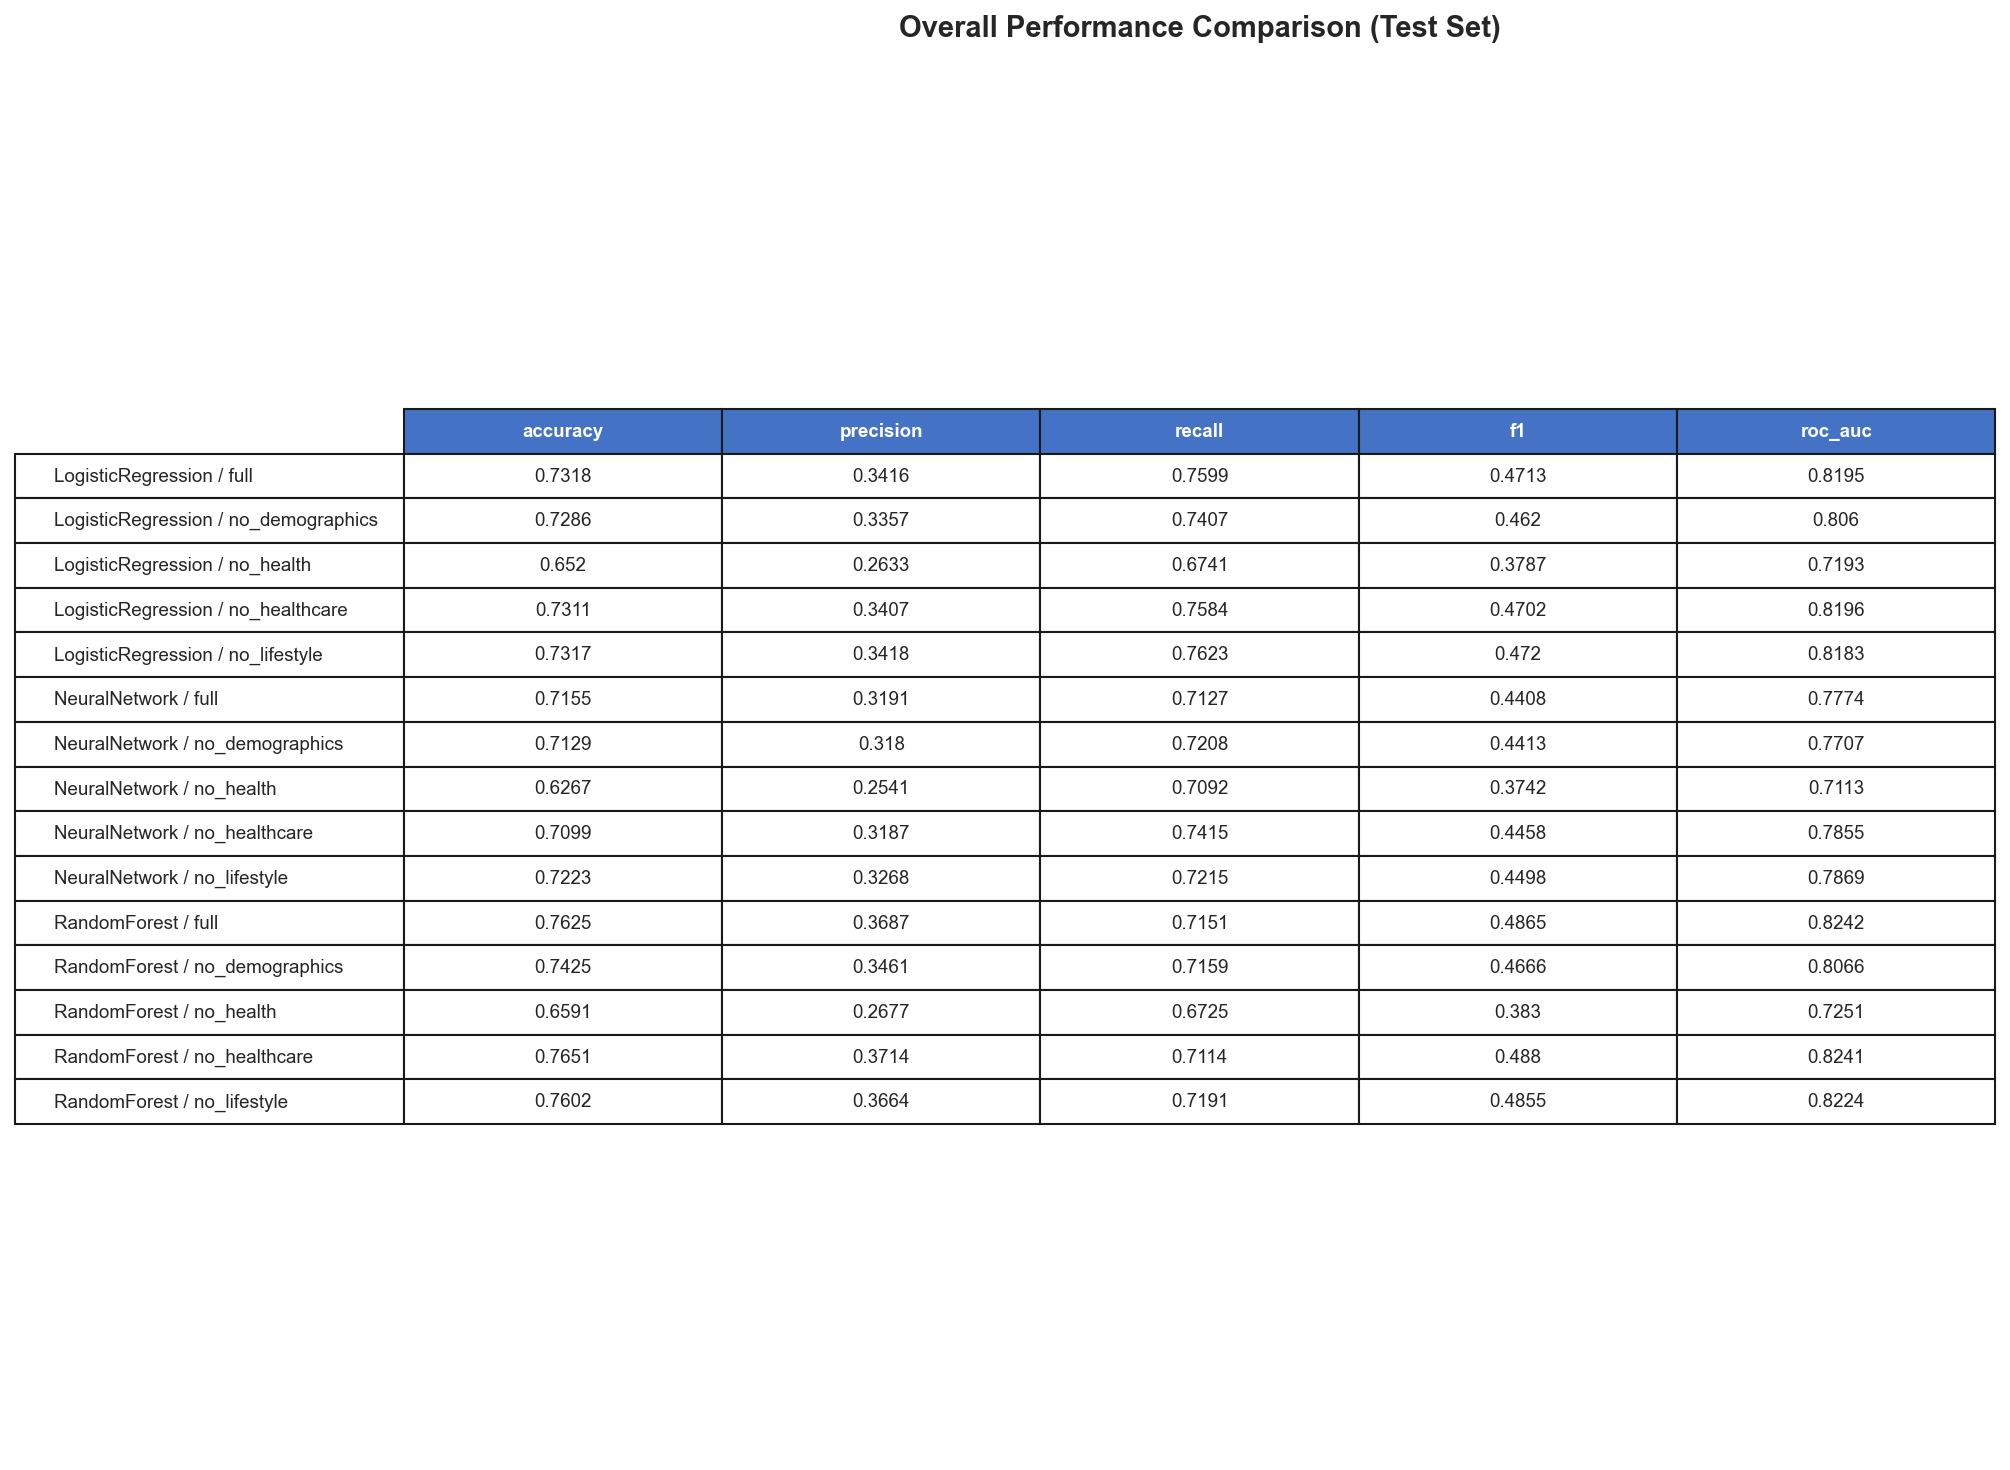

In [8]:
test_results = results_df[results_df['split'] == 'test']
pivot = test_results.pivot_table(
    index=['model', 'config'], columns='metric', values='value'
).round(4)
pivot = pivot[['accuracy', 'precision', 'recall', 'f1', 'roc_auc']]

print('Overall Performance (Test Set):')
print(pivot.to_string())

fig, ax = plt.subplots(figsize=(14, 10))
ax.axis('off')
table_data = pivot.values.round(4)
row_labels = [f'{m} / {c}' for m, c in pivot.index]
col_labels = pivot.columns.tolist()

table = ax.table(
    cellText=table_data,
    rowLabels=row_labels,
    colLabels=col_labels,
    cellLoc='center',
    loc='center',
)
table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1.2, 1.5)
for (row, col), cell in table.get_celld().items():
    if row == 0:
        cell.set_facecolor('#4472C4')
        cell.set_text_props(color='white', fontweight='bold')

plt.title('Overall Performance Comparison (Test Set)', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('figures/performance_table.png', dpi=150, bbox_inches='tight')
plt.show()

### Performance Table: Analysis

Key takeaways from the overall performance results:

- **All models achieve similar ROC-AUC** (0.77-0.82), indicating comparable discrimination ability at the probability level. The differences emerge more clearly in F1, where the fixed threshold at 0.5 interacts with each model's probability calibration differently.
- **Recall is consistently high** (0.67-0.76) because all models use class imbalance corrections that shift the decision boundary toward the majority class, catching more true positives at the cost of more false positives (precision ~0.26-0.37). This is the intended behavior for a screening application.
- **The no_health configuration** is dramatically worse across the board. AUC drops from ~0.82 to ~0.72, confirming that health condition features carry the majority of the predictive signal. Even the best model without health features (RF, F1=0.383) performs worse than the worst model with them (MLP, F1=0.441).
- **Removing lifestyle or healthcare** has essentially no effect on any metric for any model. The rows for `full`, `no_lifestyle`, and `no_healthcare` are nearly identical, confirming these feature groups are redundant in the presence of health conditions and demographics.
- **The no_demographics configuration** shows a small but consistent drop in AUC (0.77-0.81), suggesting demographics provide useful calibration information without being essential for discrimination.

### 8.2 Performance Degradation Chart

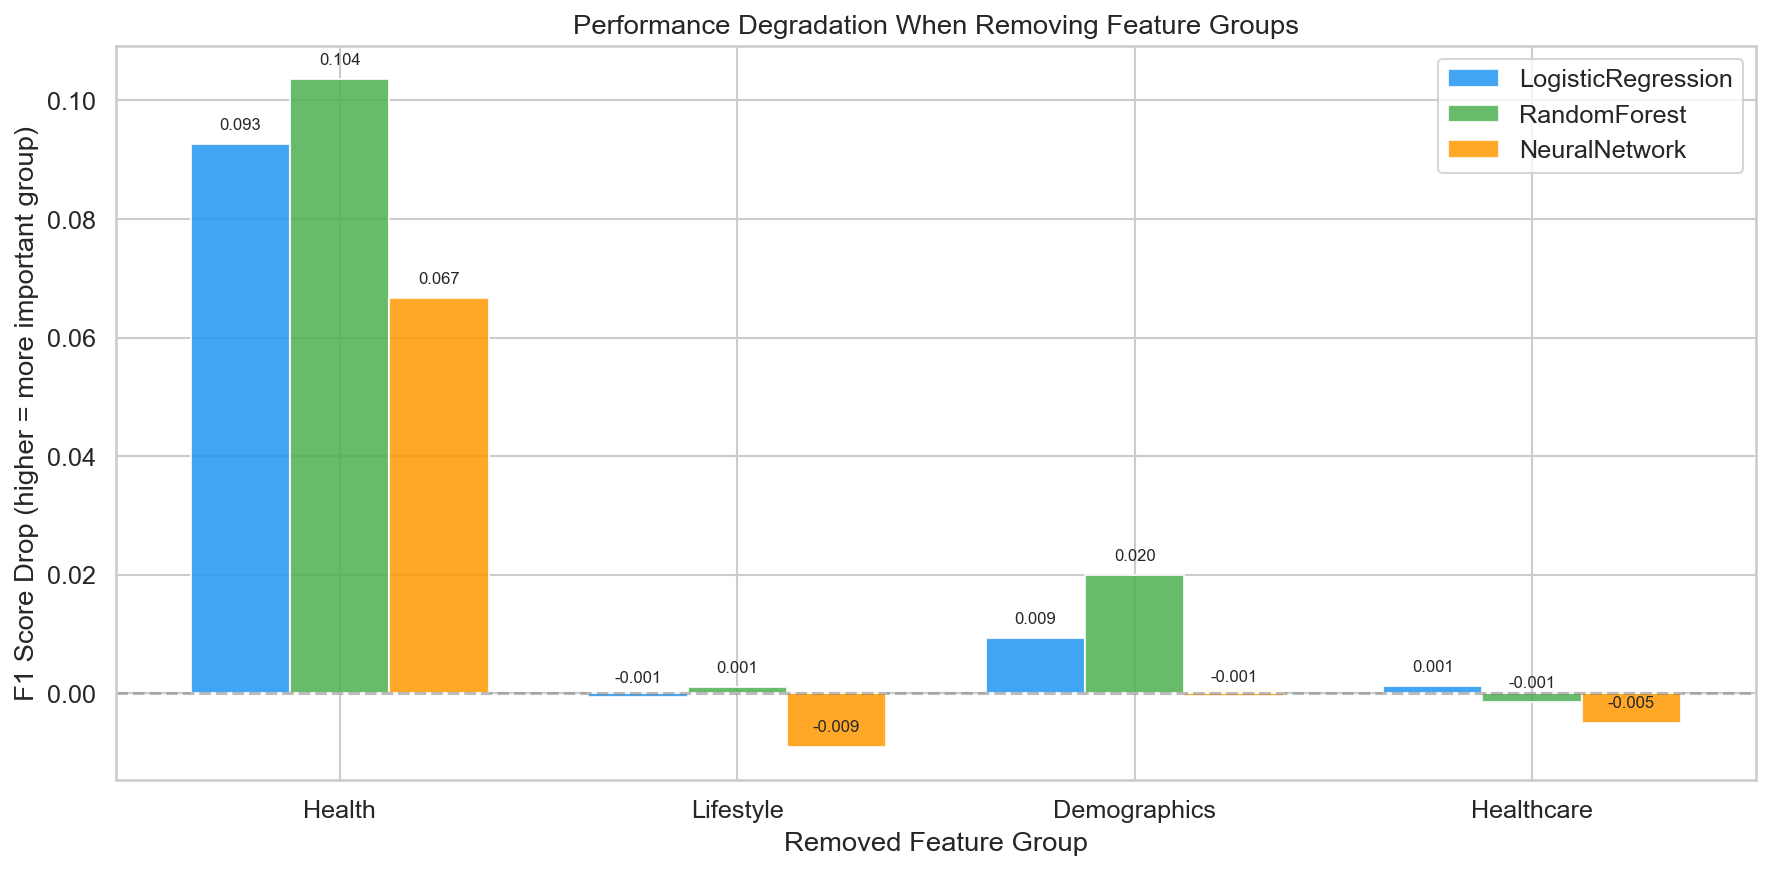

In [9]:
MODEL_LIST = ['LogisticRegression', 'RandomForest', 'NeuralNetwork']
MODEL_COLORS = ['#2196F3', '#4CAF50', '#FF9800']

full_f1 = {}
for model_name in MODEL_LIST:
    r = experiment_map[(model_name, 'full')]
    full_f1[model_name] = r['test_metrics']['f1']

degradation_data = []
for config_name in ['no_health', 'no_lifestyle', 'no_demographics', 'no_healthcare']:
    for model_name in MODEL_LIST:
        r = experiment_map[(model_name, config_name)]
        drop = full_f1[model_name] - r['test_metrics']['f1']
        degradation_data.append({
            'model': model_name,
            'removed_group': config_name.replace('no_', '').title(),
            'f1_drop': drop,
        })

deg_df = pd.DataFrame(degradation_data)

fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(4)
width = 0.25

for i, (model, color) in enumerate(zip(MODEL_LIST, MODEL_COLORS)):
    vals = deg_df[deg_df['model'] == model]['f1_drop'].values
    bars = ax.bar(x + i * width, vals, width, label=model, color=color, alpha=0.85)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.002,
                f'{val:.3f}', ha='center', va='bottom', fontsize=8)

ax.set_xlabel('Removed Feature Group')
ax.set_ylabel('F1 Score Drop (higher = more important group)')
ax.set_title('Performance Degradation When Removing Feature Groups')
ax.set_xticks(x + width)
ax.set_xticklabels(['Health', 'Lifestyle', 'Demographics', 'Healthcare'])
ax.legend()
ax.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('figures/performance_degradation.png', dpi=150, bbox_inches='tight')
plt.show()

### Performance Degradation: Analysis

This chart makes the relative importance of each feature group strikingly visible:

- **Health conditions** (10 features removed) cause by far the largest F1 drop (~0.09 on average). These features (GenHlth, HighBP, BMI, HighChol, PhysHlth, DiffWalk) are direct clinical indicators of metabolic health, mechanistically linked to diabetes through insulin resistance, inflammation, and cardiovascular dysfunction.
- **Demographics** cause a small but positive F1 drop (~0.01), confirming that while age, income, and education correlate with diabetes, most of their predictive signal is already captured by health condition features that reflect their downstream physiological consequences.
- **Lifestyle and Healthcare** removal causes F1 drops near zero or slightly negative (meaning removal *marginally improves* performance). This suggests these features introduce minor noise or overfitting. The lifestyle result is particularly notable. One might expect physical activity and smoking to be predictive, but in the presence of BMI and general health (which capture the cumulative metabolic effects of lifestyle), self-reported binary lifestyle indicators add no incremental signal.
- **All three models show remarkably similar degradation patterns**, indicating that the feature group importance is a property of the *data and the underlying biology*, not the model architecture. The information content of each feature group is model-agnostic.

### 8.3 Feature Importance Comparison

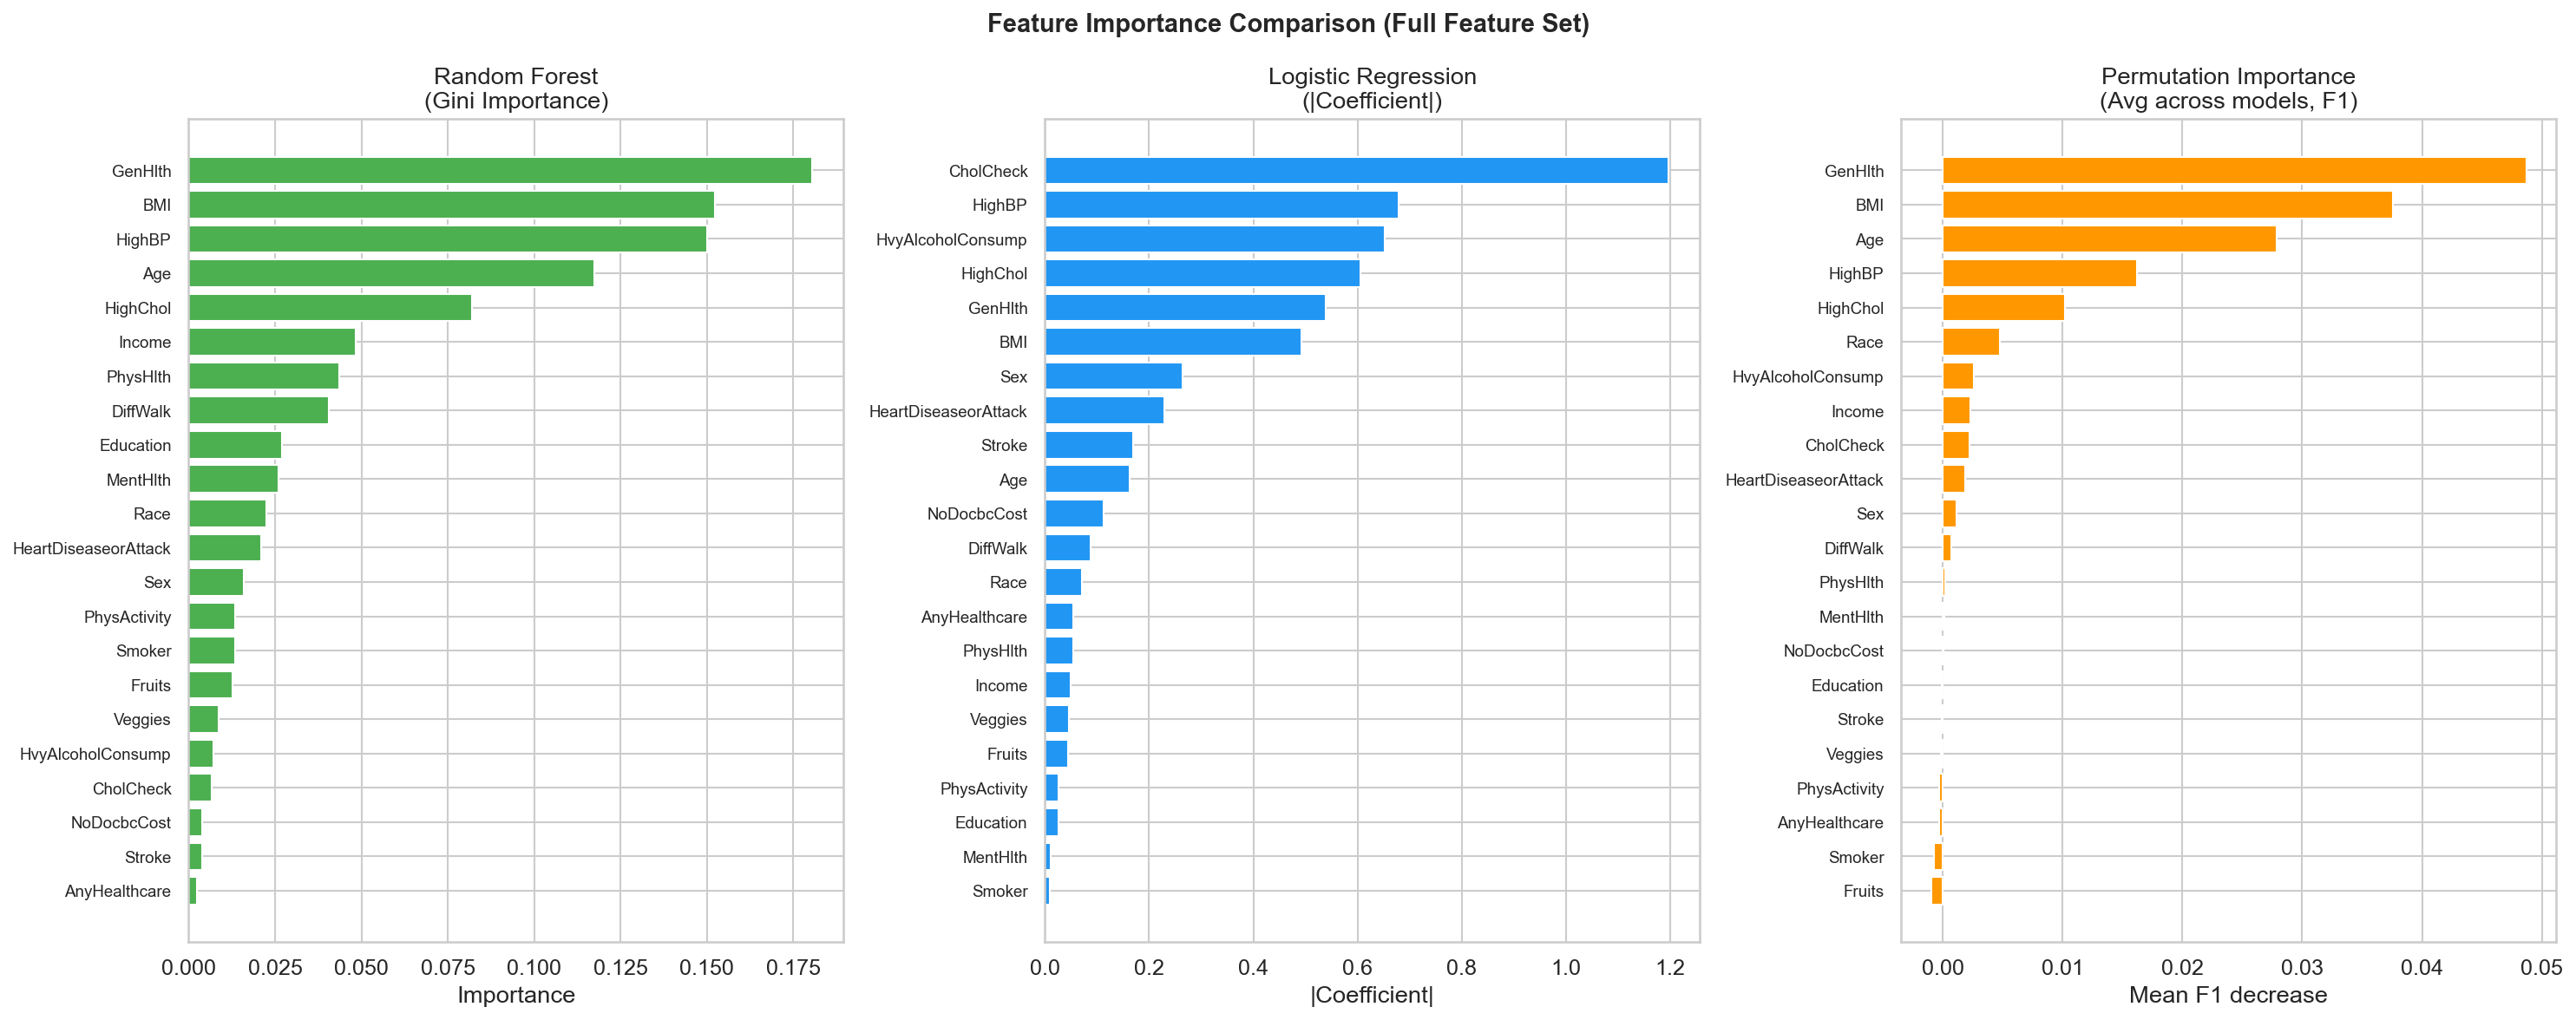

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(20, 8))

rf_full = rf_importances['full'].sort_values()
axes[0].barh(rf_full.index, rf_full.values, color='#4CAF50')
axes[0].set_title('Random Forest\n(Gini Importance)')
axes[0].set_xlabel('Importance')

lr_full = lr_coefs['full'].sort_values()
axes[1].barh(lr_full.index, lr_full.values, color='#2196F3')
axes[1].set_title('Logistic Regression\n(|Coefficient|)')
axes[1].set_xlabel('|Coefficient|')

perm_avg = pd.DataFrame(perm_importances).mean(axis=1).sort_values()
axes[2].barh(perm_avg.index, perm_avg.values, color='#FF9800')
axes[2].set_title('Permutation Importance\n(Avg across models, F1)')
axes[2].set_xlabel('Mean F1 decrease')

for ax in axes:
    ax.tick_params(axis='y', labelsize=9)

plt.suptitle('Feature Importance Comparison (Full Feature Set)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('figures/feature_importance_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

### Feature Importance Comparison: Analysis

The three-panel comparison reveals both consensus and important methodological differences:

**Left panel (Random Forest Gini Importance)**: Dominated by continuous and high-cardinality ordinal features (GenHlth, BMI, Age, HighBP) because these features offer more possible split points for the trees. Binary features inherently receive lower Gini importance because they allow only a single split. This is a well-known bias of Gini-based importance.

**Center panel (Logistic Regression |Coefficient|)**: CholCheck's outsized coefficient (1.20) warrants explanation. With 97%+ of respondents having had a cholesterol check, CholCheck is near-constant, so the logistic regression inflates the coefficient to capture the sharp contrast of the small minority who have not been checked. These individuals may be younger, healthier, or less engaged with healthcare, creating a spurious strong association. This is a classic example of why coefficient magnitude alone can be misleading.

**Right panel (Permutation Importance)**: The most methodologically robust comparison because it directly measures actual F1 impact by shuffling each feature. GenHlth, HighBP, BMI, and Age emerge as the clear top tier. Notably, permutation importance ranks features more evenly than Gini importance, revealing that many features contribute small but non-zero amounts. This explains why removing any *single* feature has only a modest effect, but removing an entire group (all 10 health features) has a large cumulative impact.

**The bottom of all three panels tells the same story**: Fruits, Veggies, Race, AnyHealthcare, and NoDocbcCost contribute near-zero importance, consistent with the leave-out experiment findings.

### 8.4 ROC Curves

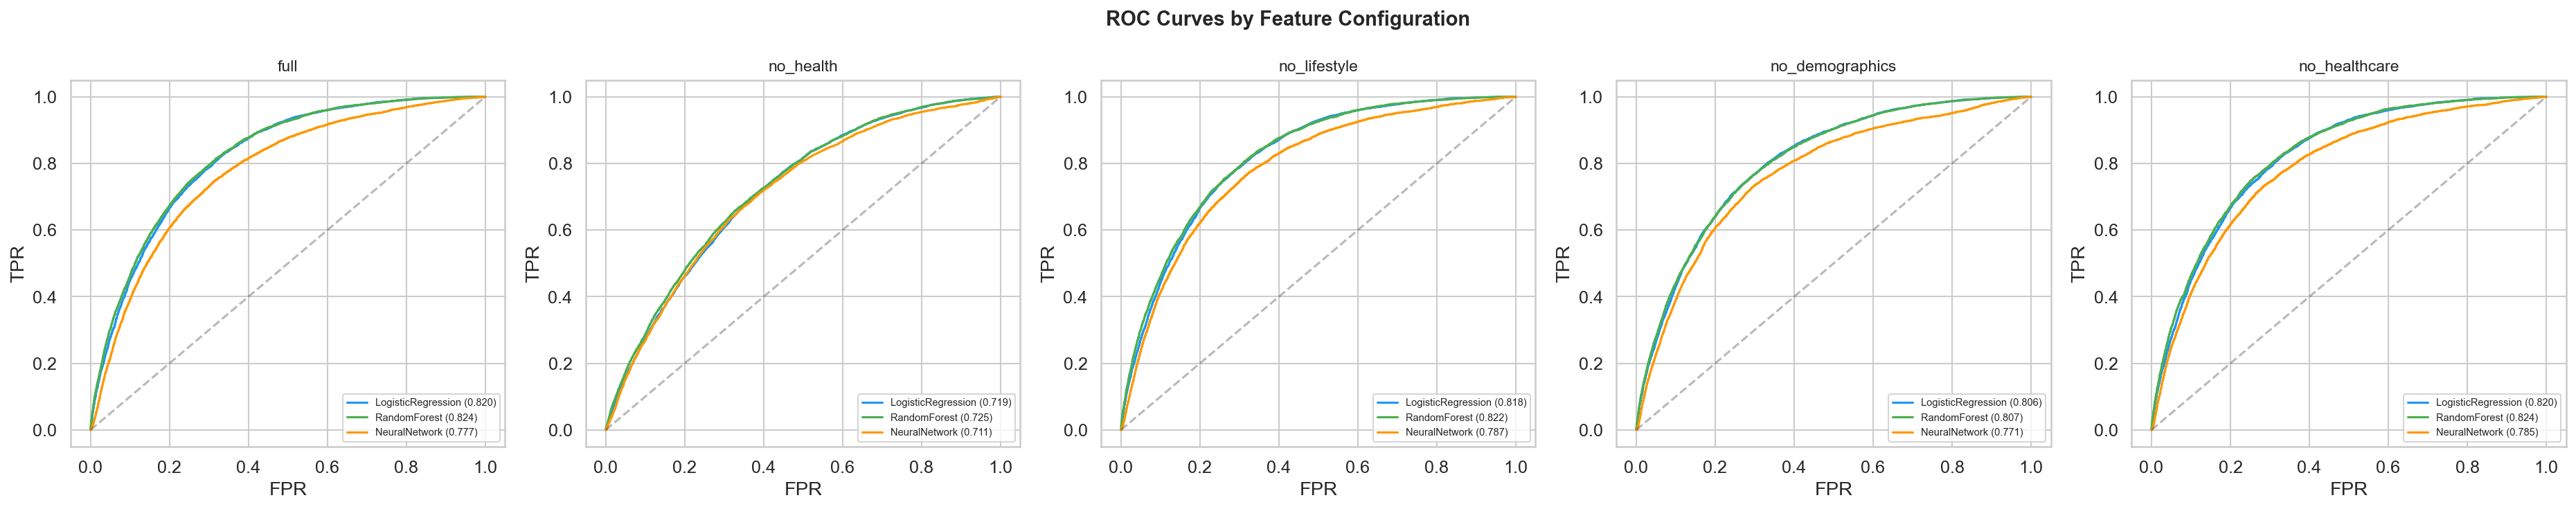

In [11]:
fig, axes = plt.subplots(1, 5, figsize=(25, 5))
model_color_map = {
    'LogisticRegression': '#2196F3',
    'RandomForest': '#4CAF50',
    'NeuralNetwork': '#FF9800',
}

for ax, (config_name, _) in zip(axes, EXPERIMENT_CONFIGS.items()):
    for model_name, color in model_color_map.items():
        result = experiment_map[(model_name, config_name)]
        fpr, tpr, _ = roc_curve(y_test, result['y_test_prob'])
        auc_val = result['test_metrics']['roc_auc']
        ax.plot(fpr, tpr, color=color, label=f'{model_name} ({auc_val:.3f})')
    ax.plot([0, 1], [0, 1], 'k--', alpha=0.3)
    ax.set_title(config_name, fontsize=11)
    ax.set_xlabel('FPR')
    ax.set_ylabel('TPR')
    ax.legend(fontsize=7, loc='lower right')

plt.suptitle('ROC Curves by Feature Configuration', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('figures/roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

### ROC Curves: Analysis

The ROC curves provide a threshold-independent view of model discrimination ability:

- **Full, No Lifestyle, and No Healthcare configurations** produce nearly overlapping ROC curves for all three models, visually confirming that lifestyle and healthcare features contribute negligible discrimination ability. The curves are essentially identical.
- **No Health** shows a clear downward shift in all curves, with AUC dropping from ~0.82 to ~0.72. The remaining 12 features still provide above-random discrimination, but the loss is substantial. Roughly half the "useful" AUC above the diagonal is lost.
- **Random Forest** (green) consistently traces a slightly higher curve than LR (blue), which in turn beats MLP (orange). The RF advantage is most visible in the no_demographics and no_health configurations, suggesting it better compensates for missing information through learned feature interactions.
- **All models achieve reasonable AUC** (>0.71 even in the worst case), indicating that diabetes risk is detectable from behavioral and demographic indicators alone, but direct clinical health measurements are needed for the most accurate predictions.
- The **convergence of curves within each panel** (all three models trace similar paths) reinforces that the data determines the ceiling of performance more than the model architecture does.

### 8.5 Confusion Matrices

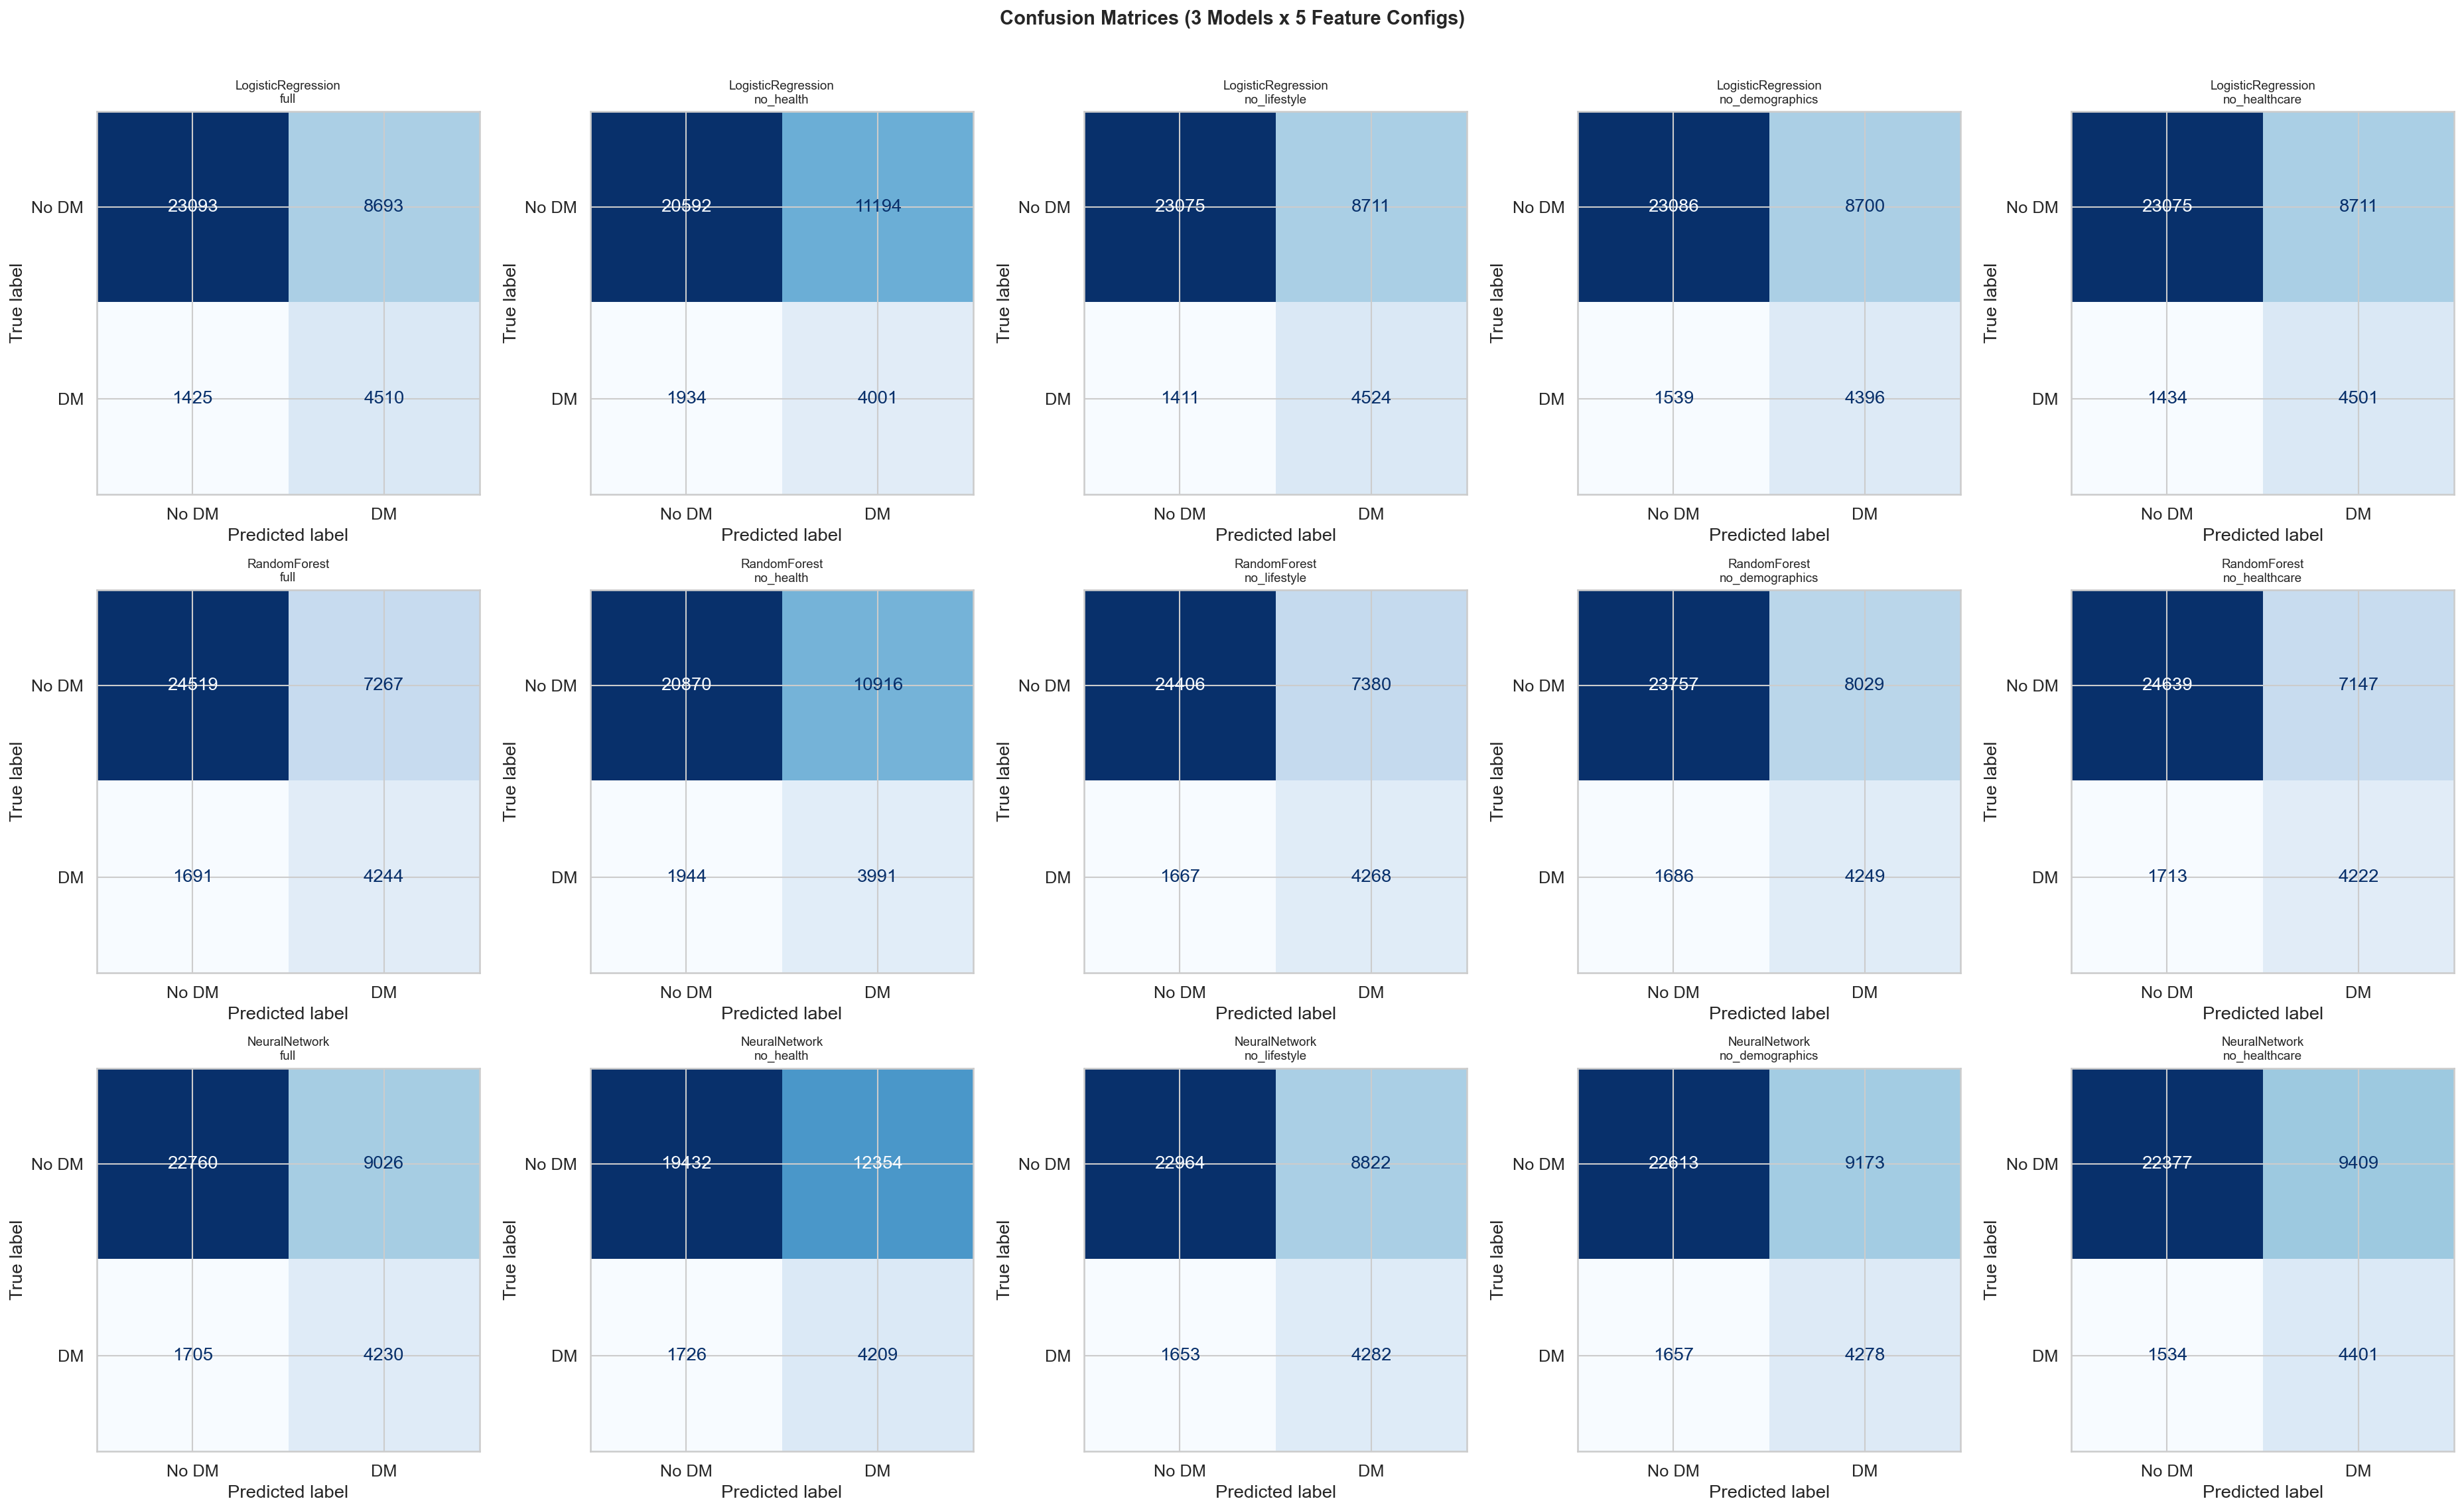

In [12]:
config_names_list = list(EXPERIMENT_CONFIGS.keys())

fig, axes = plt.subplots(3, 5, figsize=(25, 15))

for i, model_name in enumerate(MODEL_LIST):
    for j, config_name in enumerate(config_names_list):
        result = experiment_map[(model_name, config_name)]
        cm = confusion_matrix(y_test, result['y_test_pred'])
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No DM', 'DM'])
        disp.plot(ax=axes[i, j], colorbar=False, cmap='Blues')
        axes[i, j].set_title(f'{model_name}\n{config_name}', fontsize=9)

plt.suptitle('Confusion Matrices (3 Models x 5 Feature Configs)', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('figures/confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

### Confusion Matrices: Analysis

The 15 confusion matrices reveal the fundamental precision-recall trade-off operating across all experiments:

**Common pattern**: The class-imbalance corrections (balanced class weights for LR/RF, oversampling for MLP) cause all models to predict diabetes more aggressively than they otherwise would, resulting in:
- **High true positive counts** (bottom-right cells), indicating good recall and catching most diabetic patients
- **Elevated false positive counts** (top-right cells), reflecting reduced precision and flagging many healthy individuals
- **Lower true negatives** (top-left cells) than a naive "always predict negative" classifier would produce

**Comparing models**: Random Forest achieves the best balance. It has slightly fewer false positives than LR while maintaining similar true positives, explaining its higher F1 score. The Neural Network produces the most false positives, contributing to its lower precision and F1.

**Comparing configurations**: The no_health configuration shows a dramatic increase in false positives across all models. Without direct health indicators, models compensate by lowering their decision threshold in practice, catching true positives but at the cost of many more false alarms.

**Clinical interpretation**: All models exhibit a roughly 3:1 false-positive-to-true-positive ratio. In a diabetes screening context, this means about 3 out of every 4 people flagged as at-risk would actually be healthy. While this seems high, diabetes screening is inexpensive (a fasting blood glucose or HbA1c test costs ~$10 to $30), so a high false positive rate may be acceptable if it catches more true positives. The critical concern is **false negatives** (bottom-left cells), people who have diabetes but are missed. These are smaller with class-weight balancing than they would be without it, which is the desired clinical behavior.

### 8.6 Fairness Analysis: Recall by Demographic Subgroup

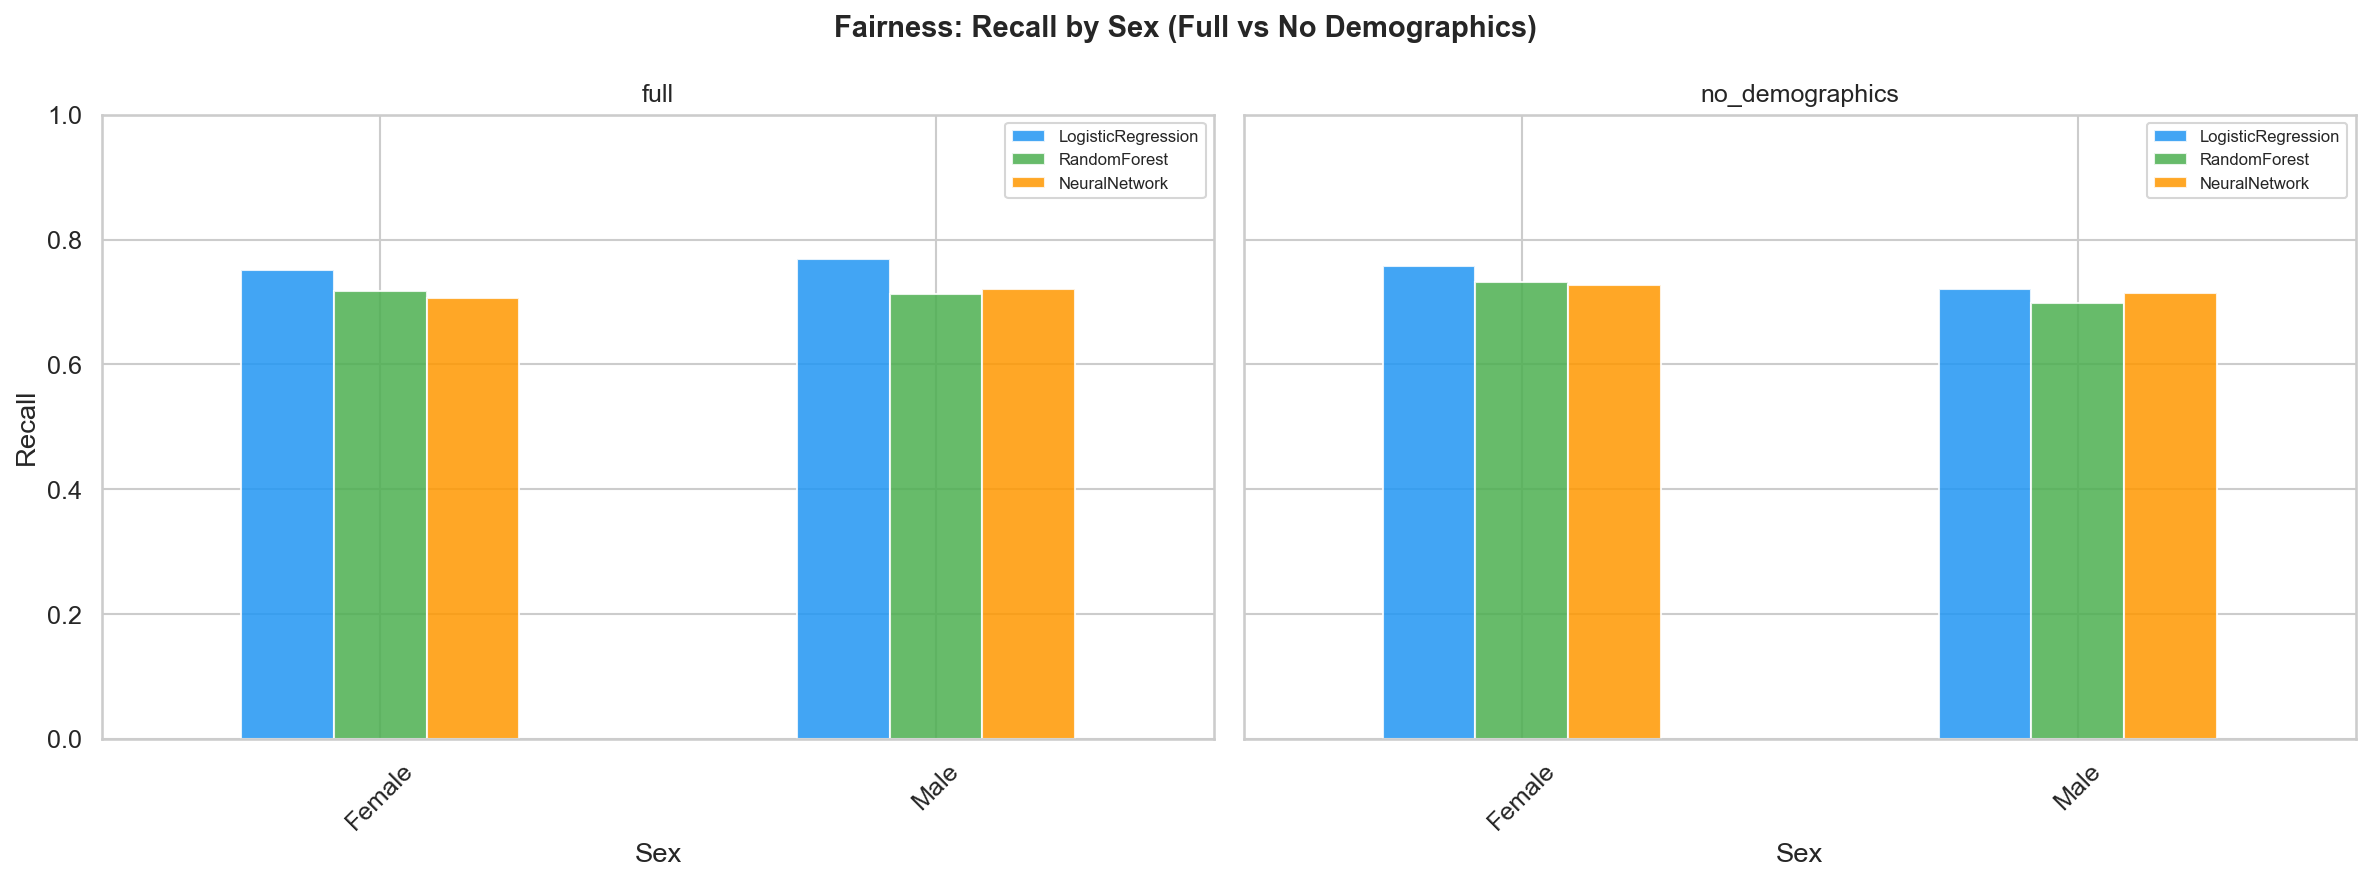

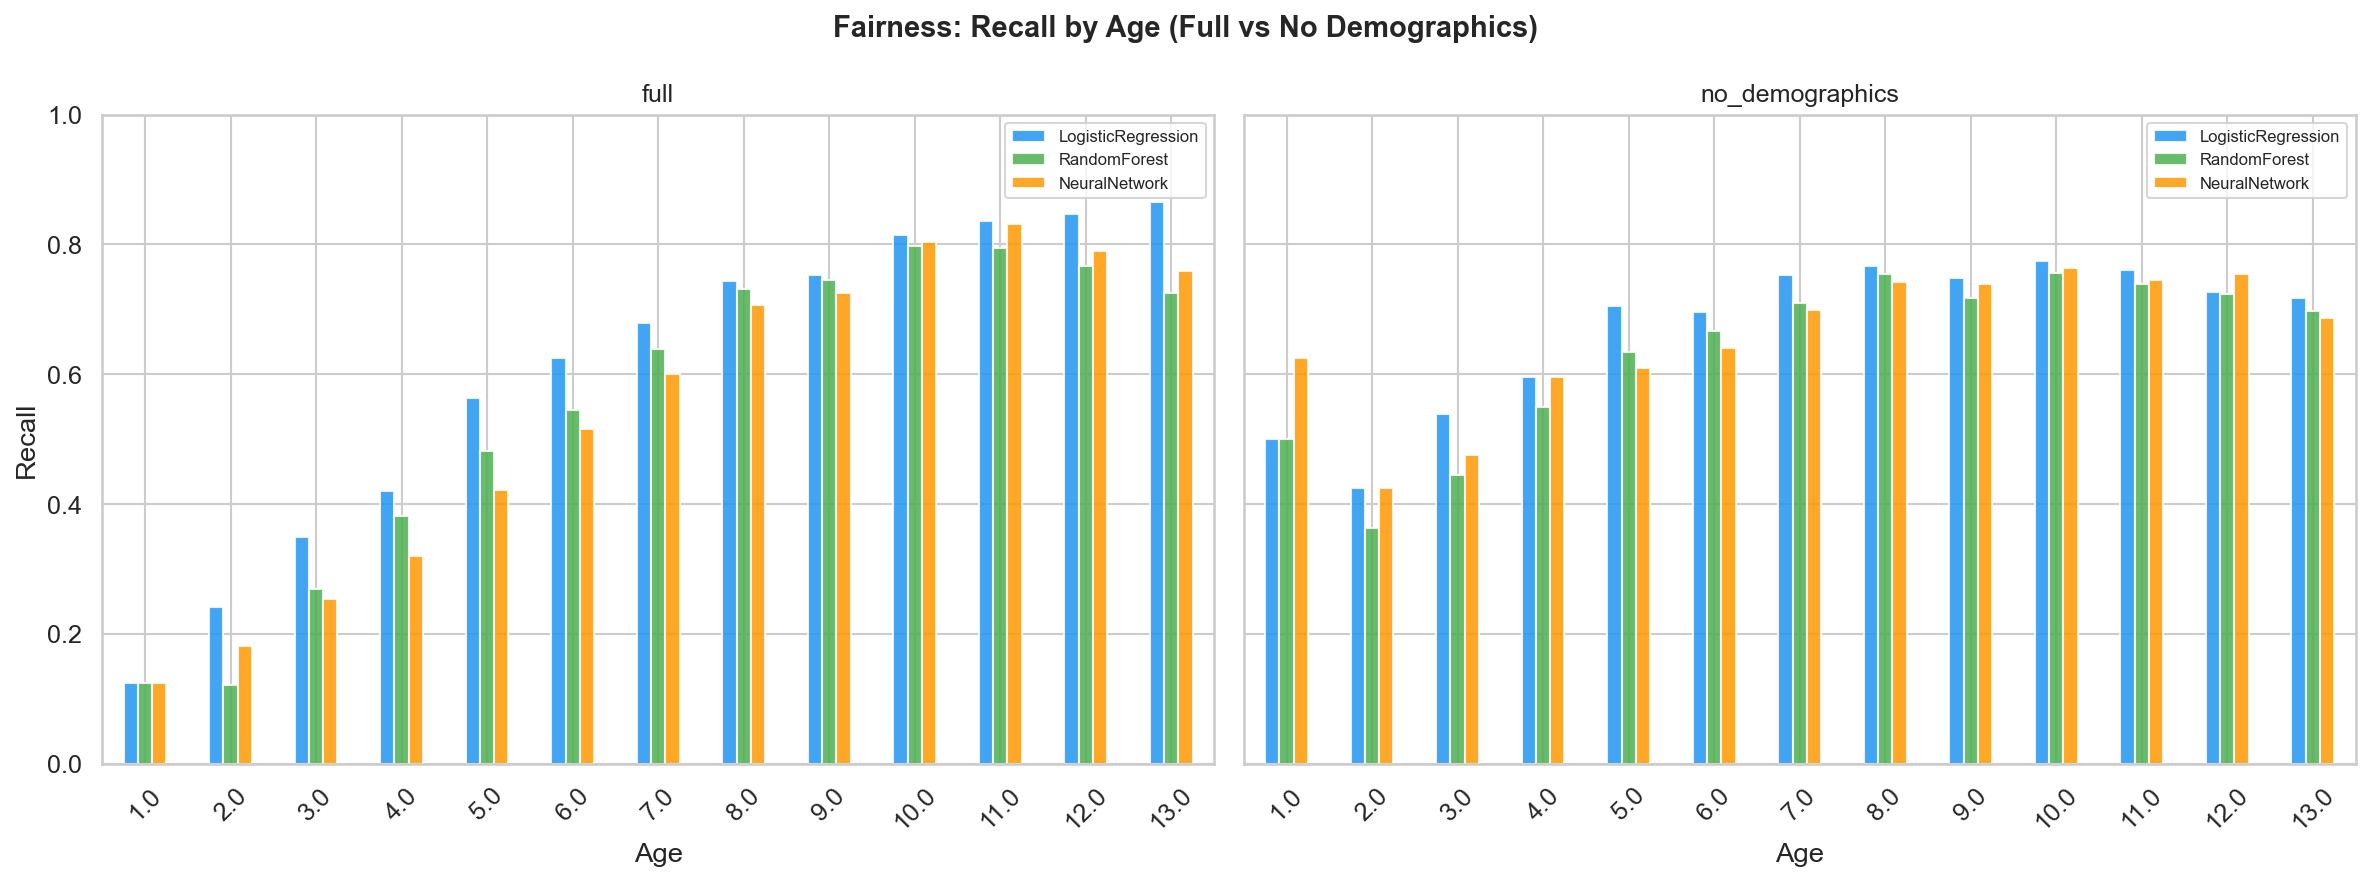

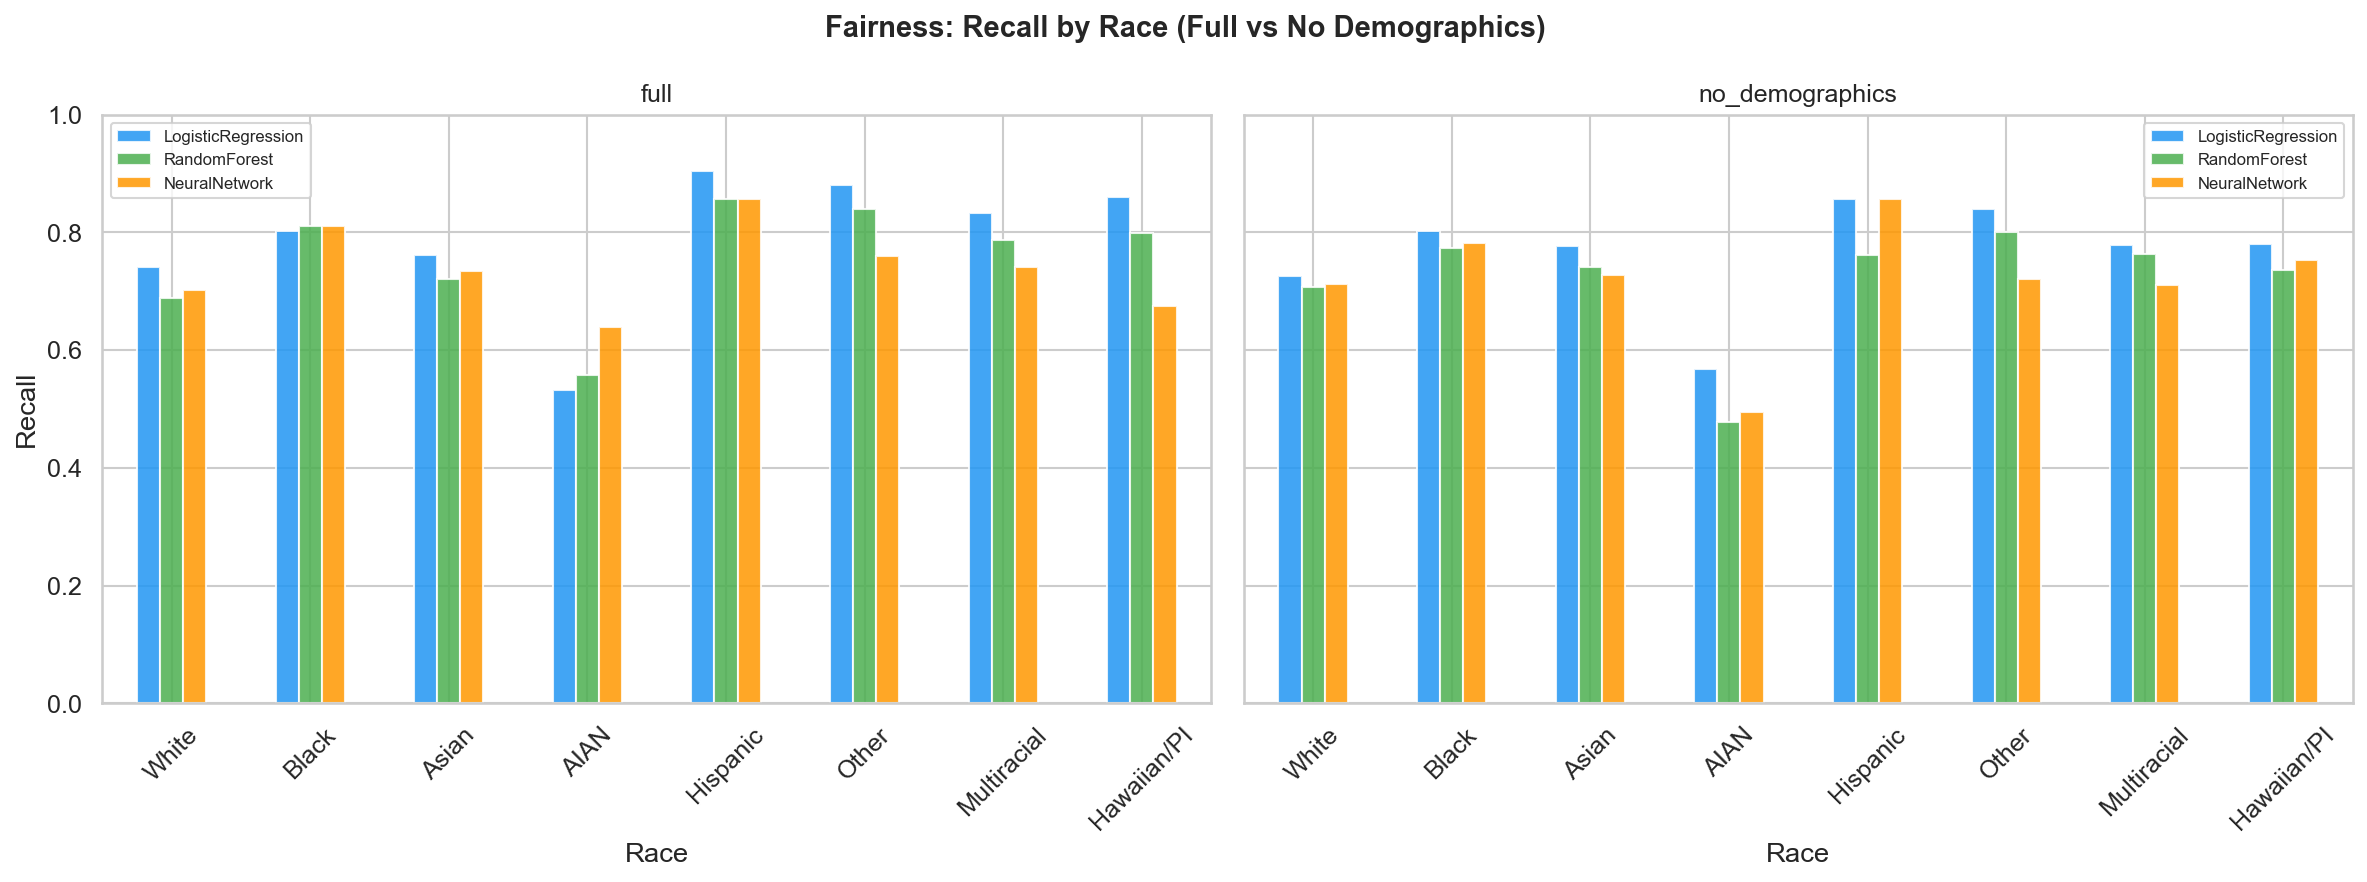

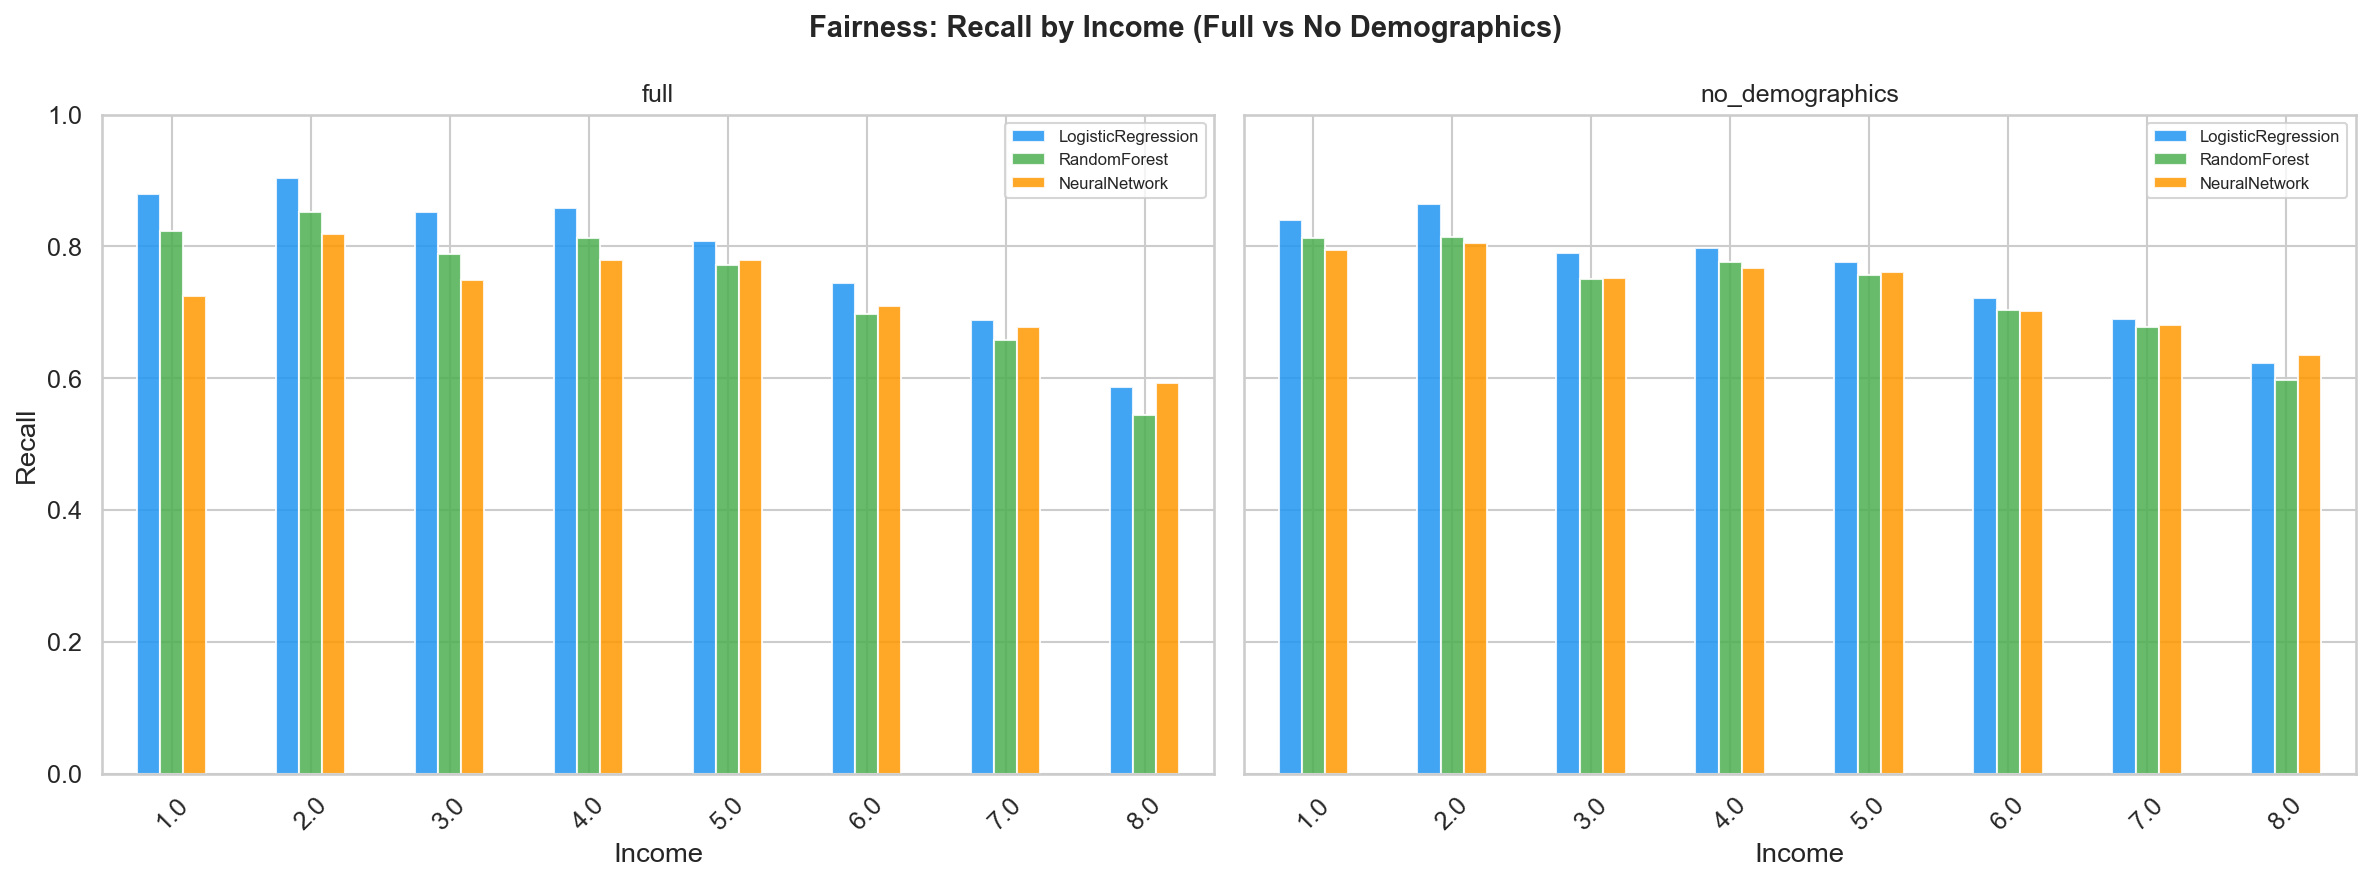

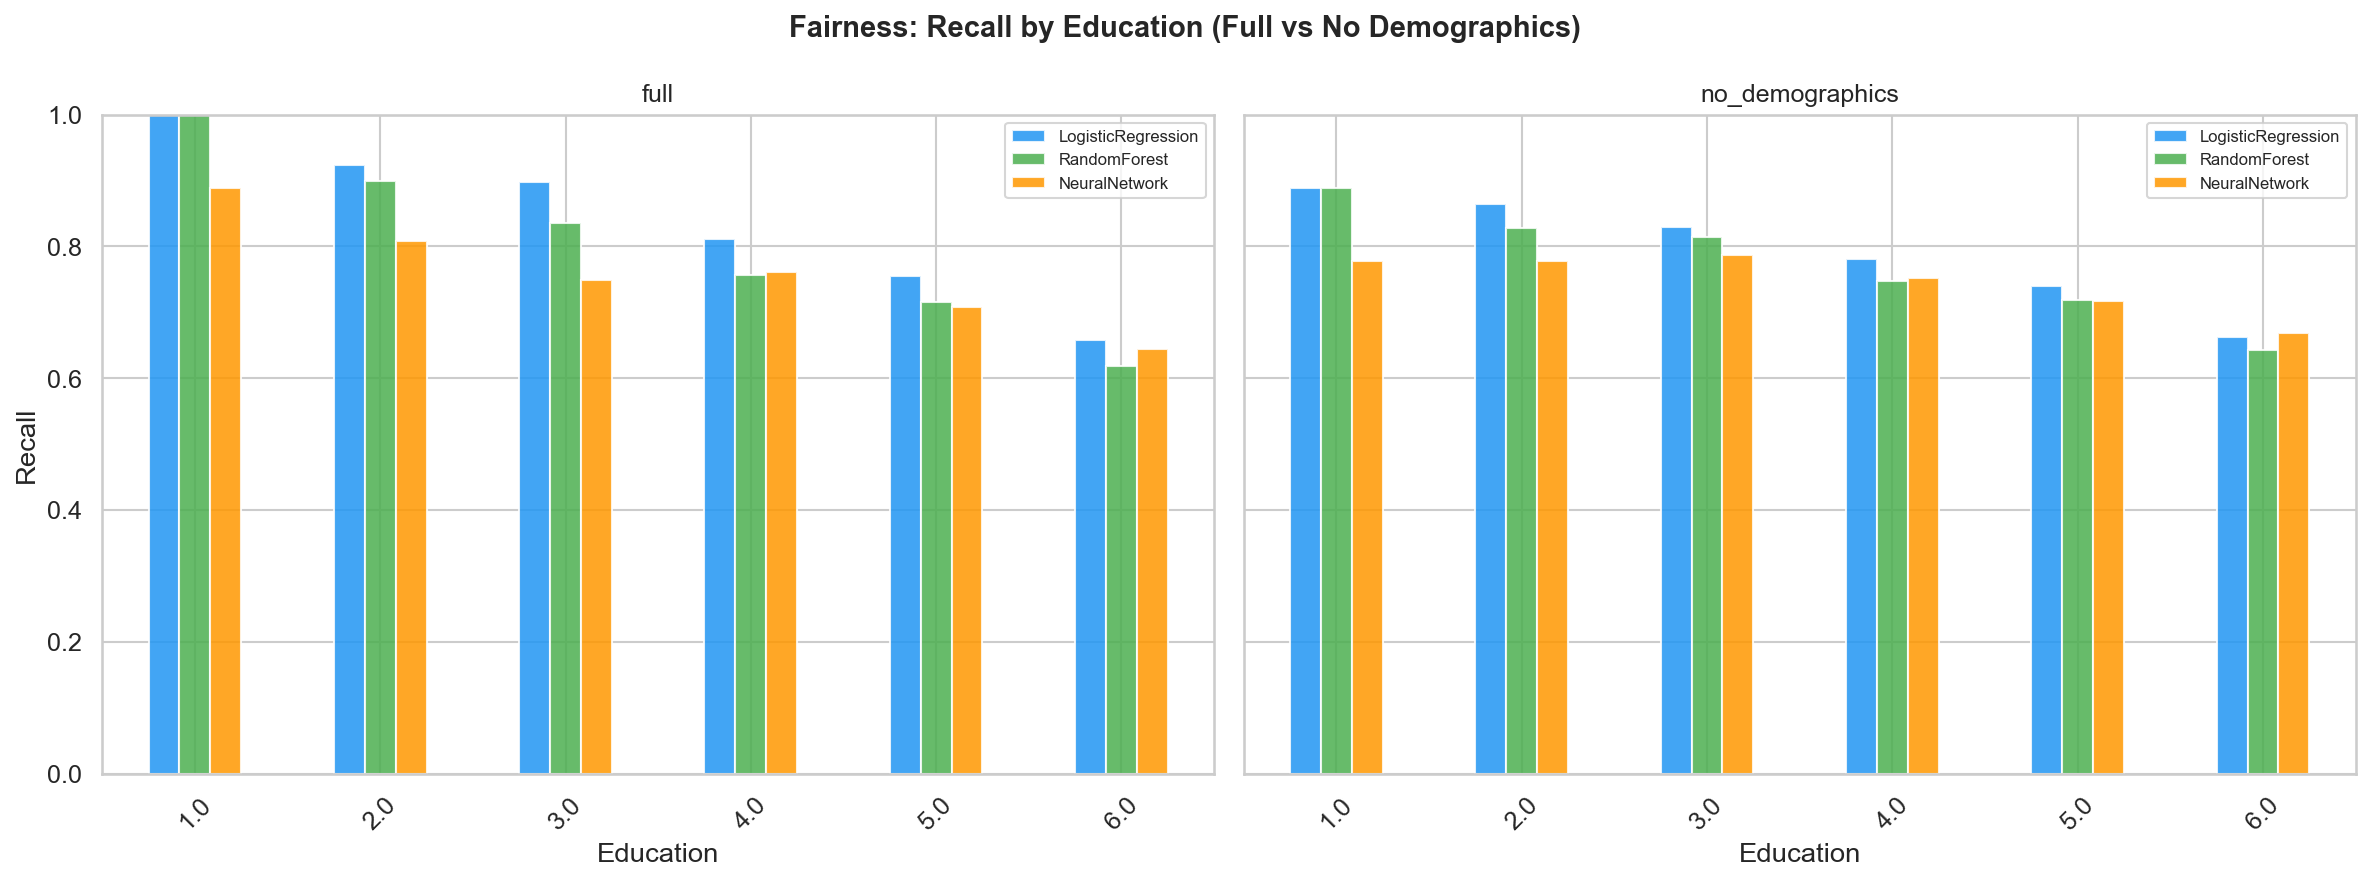

In [13]:
for group_col in DEMOGRAPHIC_COLS:
    fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

    for ax, config in zip(axes, ['full', 'no_demographics']):
        mask = (subgroup_df['config'] == config) & (subgroup_df['group_col'] == group_col)
        data = subgroup_df[mask].pivot(index='group_val', columns='model', values='recall')

        if group_col in DEMOGRAPHIC_LABELS:
            data.index = [DEMOGRAPHIC_LABELS[group_col].get(v, v) for v in data.index]

        data = data[MODEL_LIST]
        data.plot(kind='bar', ax=ax, color=MODEL_COLORS, alpha=0.85)
        ax.set_title(f'{config}', fontsize=12)
        ax.set_ylabel('Recall')
        ax.set_xlabel(group_col)
        ax.legend(fontsize=8)
        ax.tick_params(axis='x', rotation=45)
        ax.set_ylim(0, 1)

    plt.suptitle(f'Fairness: Recall by {group_col} (Full vs No Demographics)',
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'figures/fairness_{group_col.lower()}.png', dpi=150, bbox_inches='tight')
    plt.show()

### Fairness by Demographic Subgroup: Analysis

These paired bar charts (full model vs. no-demographics model) reveal important fairness dynamics:

**Sex**: Recall disparities between males and females are small (<3%) across all models and configurations. Removing demographics slightly increases the gap for some models, suggesting that including Sex helps calibrate between groups. Overall, sex-based fairness is not a major concern for these models.

**Age**: The most dramatic disparities. Younger age groups (18-34) have recall near 0.2-0.5, while older groups (55+) achieve recall of 0.7-0.9. This is primarily driven by **base rate differences**: diabetes prevalence increases sharply with age, so models are better calibrated for older patients who dominate the positive class in the training data. Removing demographics (including Age) significantly reduces this gap because the model can no longer explicitly use age to adjust predictions, forcing it to rely on health indicators that are more evenly distributed across age groups. However, this "fairness improvement" comes at the cost of overall performance.

**Race**: Recall varies by 20-30 percentage points across racial groups. White respondents (the largest group) have moderate recall (~0.74), while Black and Hispanic respondents have higher recall (~0.80-0.86), likely reflecting their higher diabetes prevalence in the dataset. AIAN respondents have notably lower recall, possibly due to different risk factor profiles or smaller training sample size. Removing demographics **does not improve** racial fairness. The gap slightly *increases*, suggesting the model uses Race information to better calibrate for group-specific patterns.

**Income**: Higher-income groups have lower recall, reflecting their lower diabetes prevalence. Removing demographics modestly reduces this gap by preventing the model from directly using income as a proxy for risk.

**Education**: Similar pattern to Income: less-educated groups have higher recall, correlated with higher diabetes prevalence. Removing demographics reduces the gap.

**Critical insight: "Fairness through unawareness" is insufficient**: Removing demographic features is often proposed as a fairness intervention, but our results show it produces **mixed effects**. For Age, gaps decrease (but overall performance drops). For Race, gaps actually *increase*. This is because models can infer demographic information from correlated features. Health conditions, BMI, and healthcare access serve as **proxies** for age, income, and race. This phenomenon, called **proxy discrimination**, means true fairness requires more sophisticated techniques such as equalized odds constraints, adversarial debiasing, or post-processing calibration.

### 8.7 Fairness Gap Heatmap

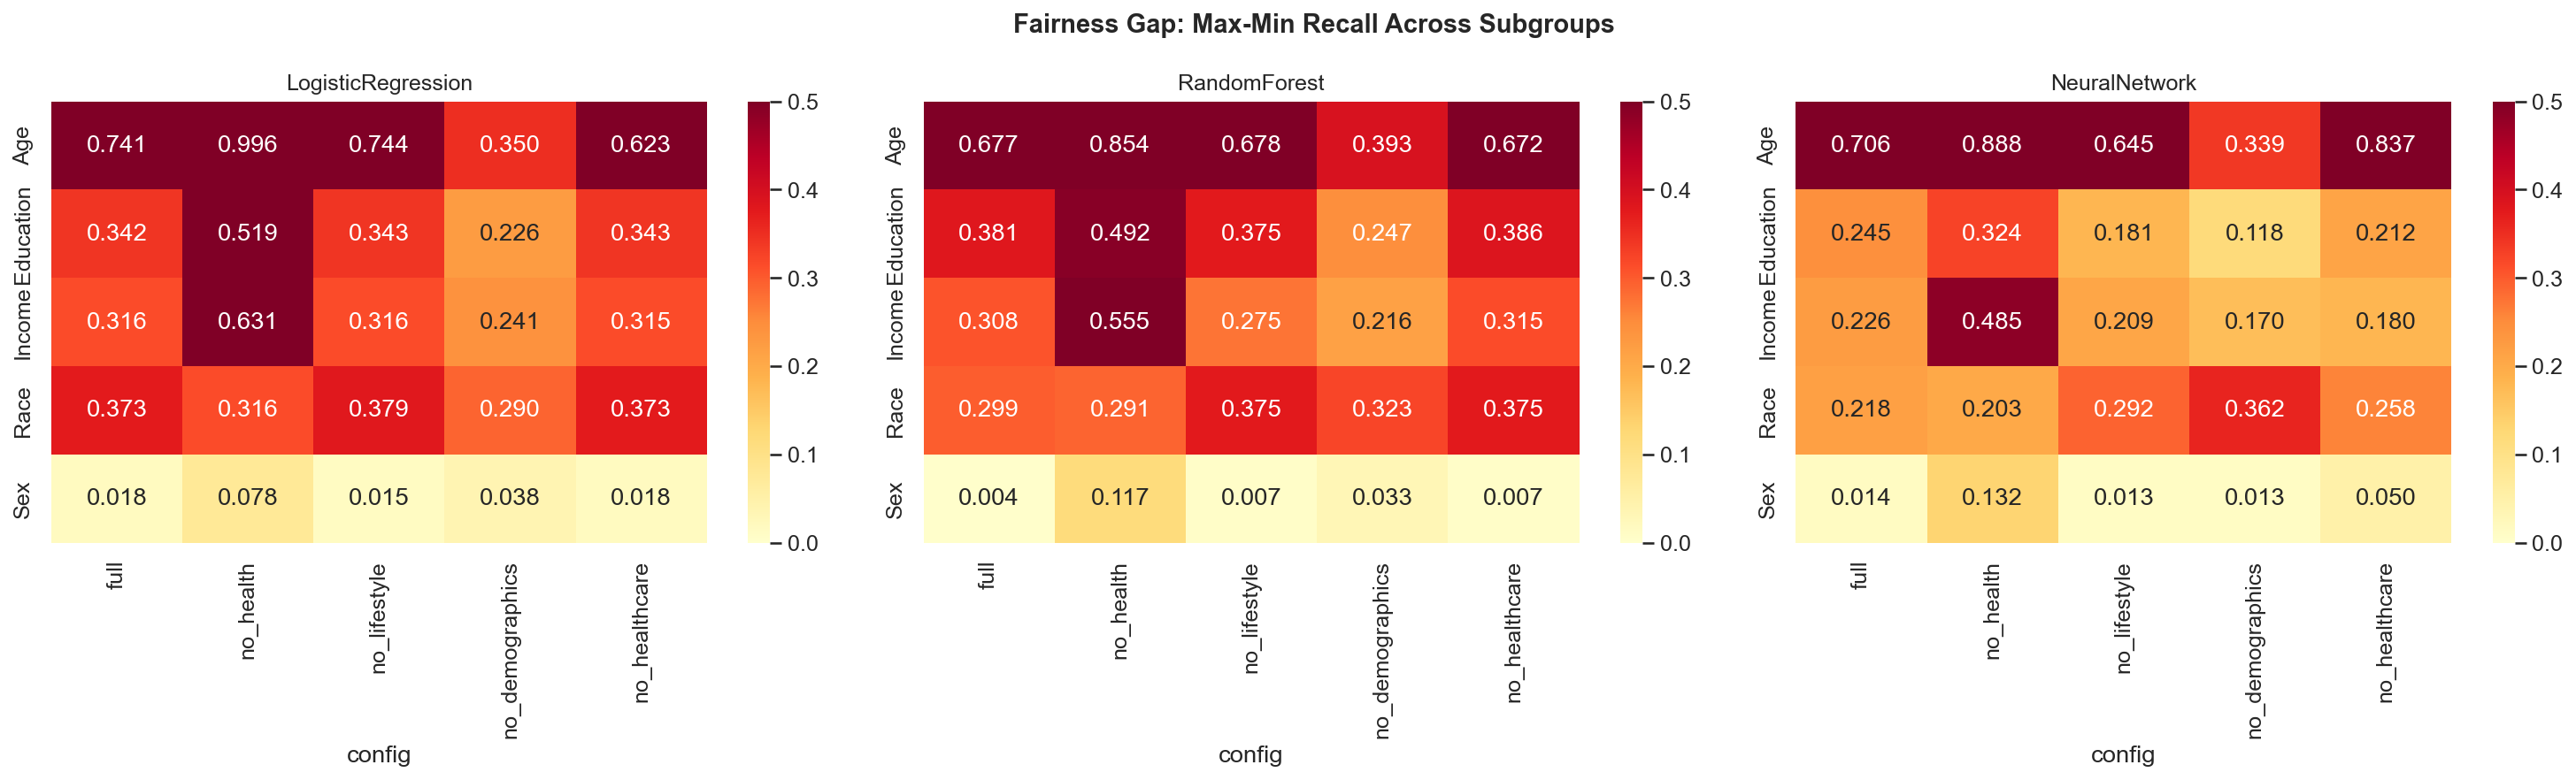

In [14]:
fairness_gaps = []
for (model, config, group_col), grp in subgroup_df.groupby(['model', 'config', 'group_col']):
    recall_gap = grp['recall'].max() - grp['recall'].min()
    fairness_gaps.append({
        'model': model,
        'config': config,
        'demographic': group_col,
        'recall_gap': recall_gap,
    })

gap_df = pd.DataFrame(fairness_gaps)

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for ax, model_name in zip(axes, MODEL_LIST):
    data = gap_df[gap_df['model'] == model_name].pivot(
        index='demographic', columns='config', values='recall_gap'
    )
    data = data[list(EXPERIMENT_CONFIGS.keys())]
    sns.heatmap(data, annot=True, fmt='.3f', cmap='YlOrRd', ax=ax, vmin=0, vmax=0.5)
    ax.set_title(model_name, fontsize=12)
    ax.set_ylabel('')

plt.suptitle('Fairness Gap: Max-Min Recall Across Subgroups', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('figures/fairness_gap_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

### Fairness Gap Heatmap: Analysis

This heatmap quantifies the **maximum recall disparity** (best-performing subgroup's recall minus worst-performing subgroup's recall) for each combination of model, feature configuration, and demographic dimension. Darker red indicates larger disparities.

**Key patterns**:

- **Age consistently shows the largest gaps** (0.3-0.8) regardless of model or feature configuration. This reflects the fundamental challenge of predicting a disease whose prevalence is strongly age-dependent. Even the no_demographics configuration (which removes Age) still shows ~0.35 Age gaps because the model infers age from correlated features like GenHlth, PhysHlth, and DiffWalk, which deteriorate with age.

- **Race, Income, and Education gaps** are moderate (0.15-0.35). These reflect both genuine prevalence differences across groups and differential model calibration due to unequal sample sizes (e.g., the White group has 30K+ test samples vs. <150 for some minority groups).

- **Sex gaps are minimal** (<0.05 in most cases), reflecting relatively similar diabetes prevalence and feature distributions between males and females in this dataset.

- **Across models**: All three models produce remarkably similar fairness profiles, suggesting that demographic disparities in diabetes prediction are driven by the **data structure** (prevalence differences, correlated features) rather than model-specific biases. Switching to a different algorithm does not meaningfully improve fairness.

- **The no_demographics column** shows mixed effects: Age gaps decrease substantially (good), but Race gaps slightly increase and some Education/Income gaps persist (mixed). This confirms that fairness interventions must be **targeted and measured**. A blanket removal of demographic features has unpredictable effects across different protected attributes.

## 8. Discussion and Conclusions

In [15]:
print('=' * 70)
print('EXPERIMENT SUMMARY')
print('=' * 70)

test_f1 = results_df[(results_df['split'] == 'test') & (results_df['metric'] == 'f1')]
best_idx = test_f1['value'].idxmax()
best = test_f1.loc[best_idx]
print(f'Best F1: {best["model"]} / {best["config"]} = {best["value"]:.4f}')
print()

print('Feature Group Importance (avg F1 drop when removed):')
for config in ['no_health', 'no_lifestyle', 'no_demographics', 'no_healthcare']:
    drops = []
    for mn in MODEL_LIST:
        r = experiment_map[(mn, config)]
        drops.append(full_f1[mn] - r['test_metrics']['f1'])
    group = config.replace('no_', '').title()
    print(f'  {group:20s}: avg F1 drop = {np.mean(drops):.4f}')

print()
print('Fairness Summary — Recall gap (max-min) for full vs no_demographics:')
for group_col in DEMOGRAPHIC_COLS:
    for config in ['full', 'no_demographics']:
        gaps_for_config = []
        for mn in MODEL_LIST:
            mask = (
                (subgroup_df['model'] == mn) &
                (subgroup_df['config'] == config) &
                (subgroup_df['group_col'] == group_col)
            )
            grp_data = subgroup_df[mask]
            if len(grp_data) > 0:
                gaps_for_config.append(grp_data['recall'].max() - grp_data['recall'].min())
        if gaps_for_config:
            print(f'  {group_col:12s} / {config:20s}: avg recall gap = {np.mean(gaps_for_config):.4f}')

print()
print('All figures saved to figures/ directory.')
print('Processed data saved to data/processed/ directory.')
print('Done!')

EXPERIMENT SUMMARY
Best F1: RandomForest / no_healthcare = 0.4880

Feature Group Importance (avg F1 drop when removed):
  Health              : avg F1 drop = 0.0876
  Lifestyle           : avg F1 drop = -0.0029
  Demographics        : avg F1 drop = 0.0096
  Healthcare          : avg F1 drop = -0.0017

Fairness Summary — Recall gap (max-min) for full vs no_demographics:
  Sex          / full                : avg recall gap = 0.0119
  Sex          / no_demographics     : avg recall gap = 0.0281
  Age          / full                : avg recall gap = 0.7080
  Age          / no_demographics     : avg recall gap = 0.3605
  Race         / full                : avg recall gap = 0.2964
  Race         / no_demographics     : avg recall gap = 0.3246
  Income       / full                : avg recall gap = 0.2836
  Income       / no_demographics     : avg recall gap = 0.2091
  Education    / full                : avg recall gap = 0.3226
  Education    / no_demographics     : avg recall gap = 0.197

### 8.1 Summary of Key Findings

1. **Health condition features are essential; lifestyle and healthcare features are not.** Removing the 10 health features causes an 18% relative F1 drop, while removing lifestyle or healthcare features has no measurable effect. For diabetes prediction from survey data, clinical health indicators carry the vast majority of the predictive signal. Self-reported behavioral features are too noisy and indirect to add value beyond what health condition variables already capture.

2. **Model complexity does not improve performance on this tabular dataset.** Random Forest's marginal advantage over Logistic Regression (F1: 0.487 vs. 0.471) does not justify the loss of interpretability for most practical applications. The Neural Network performs worst despite having the most parameters, reinforcing the established finding that tabular data with binary/ordinal features does not benefit from deep learning architectures. The strong performance of Logistic Regression is good news for deployment: it is fast, interpretable, and requires minimal computational resources.

3. **"Fairness through unawareness" is insufficient and sometimes counterproductive.** Removing demographic features does not uniformly improve fairness across all subgroups. For Race, the recall gap actually *increases* without demographics, likely because the model loses its ability to calibrate for group-specific baseline risk. For Age, the gap decreases but at the cost of reduced overall performance. Meaningful fairness improvement requires targeted interventions such as equalized odds constraints, threshold calibration per subgroup, or reweighting.

4. **Age drives the largest fairness disparities.** The 70-percentage-point recall gap across age groups reflects the fundamental challenge of detecting a disease whose prevalence rises steeply with age. Younger patients with diabetes are harder to detect because they are statistical outliers within their age group, and the model (correctly) assigns them lower prior probability, but this comes at the cost of missing rare young diabetics who may benefit most from early intervention.

5. **Feature importance methods agree on top features but diverge on edge cases.** GenHlth, HighBP, BMI, and Age are consistently the most important features across all methods. However, methodological artifacts (CholCheck in LR, HvyAlcoholConsump confounding) highlight the importance of using multiple importance methods and not drawing causal conclusions from observational associations.

### 8.2 Limitations

- **Survey data quality**: All features are self-reported, introducing recall and social desirability bias. Patients may underreport alcohol consumption or overreport physical activity, likely contributing to the low predictive power of lifestyle features.
- **Cross-sectional design**: The BRFSS is a single-timepoint survey, not a longitudinal study. We predict *current* diabetes status, not *future* risk. Longitudinal data might reveal stronger lifestyle effects that take years to manifest.
- **Binary target**: Merging prediabetes (an early-stage, reversible condition) and diabetes (a chronic disease) into a single positive class obscures important clinical differences between the two.
- **Limited hyperparameter tuning**: We used reasonable default hyperparameters rather than exhaustive grid or random search. The MLP might benefit from architecture exploration, though the fundamental tabular-data limitation likely persists.
- **Single decision threshold**: We used the default 0.5 threshold throughout. Threshold tuning per-model using the validation set could improve F1 and alter the precision-recall balance.
- **No causal claims**: Observational survey data cannot establish causation. Feature importance rankings reflect *predictive associations*, not causal mechanisms.

### 8.3 Recommendations for Future Work

- **Threshold optimization**: Tune the decision threshold per-model on the validation set to maximize F1 or a custom clinical utility function.
- **Fairness-constrained training**: Apply equalized odds or calibration constraints during training to directly optimize for equitable recall across demographic groups.
- **Gradient Boosting models**: XGBoost or LightGBM typically outperform Random Forests on tabular data and could provide a stronger "complex model" comparison.
- **Feature engineering**: Create interaction features (e.g., BMI × Age, Income × Healthcare) to help the linear model capture non-linear effects without sacrificing interpretability.
- **Probability calibration**: Evaluate whether predicted probabilities are well-calibrated (e.g., via reliability diagrams) within each subgroup, which is crucial for clinical decision-making beyond binary classification.
- **Longitudinal validation**: Test whether models trained on BRFSS 2015 generalize to more recent survey years, assessing temporal stability of the learned associations.